# Avaliação do Framework CNN-RAG-SLM — versão limpa para artigo (RAG context fix)

Notebook de pós-processamento dos resultados gerados pelos modelos **Mistral**, **Qwen**, **TinyLlama** e **Zephyr**.

Esta versão foi reestruturada para ficar alinhada à metodologia atual do artigo:

- mantém apenas métricas diretas e interpretáveis;
- remove `BLEU` da análise principal;
- remove `grounding_score` ponderado 70/30 das tabelas e figuras finais;
- remove scores compostos com pesos arbitrários (`score_quality`, `score_efficiency`, `score_overall`);
- usa **Geometric Grounding** como métrica principal de fidelidade ao RAG;
- calcula **Copy Ratio**, **Novelty** e **Grounding--Novelty Balance (GNB)** como métricas interpretativas;
- gera figuras IEEE combinadas conforme definido para o artigo.


## 1. Instalação das dependências

Execute esta célula no Colab antes das demais.

In [1]:
!pip -q install sentence-transformers==3.1.1 rouge-score bert-score sacrebleu


  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 245.3/245.3 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 48.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 20.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.19.0 requires huggingface-hub<2.0,>=1.2.0, but you have huggingface-hub 0.36.2 which is incompatible.


## 2. Imports e configuração inicial

In [2]:

import os
import re
import json
import math
import glob
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sentence_transformers import SentenceTransformer
from rouge_score import rouge_scorer

warnings.filterwarnings('ignore')

RESULTS_DIR = Path('/content/results_slm_rag_eval')
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Diretórios onde o notebook irá procurar os CSVs.
# No Colab, deixe os arquivos em /content ou faça upload manual.
SEARCH_DIRS = [Path('/content'), Path('/content/results_slm_rag'), Path('/mnt/data')]

print('Diretório de saída:', RESULTS_DIR)


/usr/local/lib/python3.12/dist-packages/sentence_transformers/cross_encoder/CrossEncoder.py:13: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm, trange


Diretório de saída: /content/results_slm_rag_eval


## 3. Upload e validação dos arquivos

Envie todos os arquivos `slm_rag_results_*.csv` e `slm_rag_grid_*.csv`.

**Opcional, mas recomendado:** envie também o arquivo `RAG_motores_eletricos.json`.

O RAG será usado apenas na avaliação, principalmente para:
- construir referências técnicas por classe;
- calcular Grounding Score com base no conhecimento original;
- evitar depender apenas do texto salvo no prompt.


In [3]:
from google.colab import files
import io

print("Selecione TODOS os CSVs (results e grid) e, se possível, o RAG_motores_eletricos.json.")
uploaded = files.upload()

dfs = {}
rag_data = None
rag_filename = None

for filename, content in uploaded.items():
    lower = filename.lower()

    if lower.endswith(".csv"):
        df = pd.read_csv(io.BytesIO(content))
        dfs[filename] = df
        print(f"✓ CSV carregado: {filename} ({len(df)} linhas, {len(df.columns)} colunas)")

    elif lower.endswith(".json") and "rag" in lower:
        rag_data = json.loads(content.decode("utf-8"))
        rag_filename = filename
        print(f"✓ RAG carregado: {filename}")

    else:
        print(f"⚠️ Ignorado: {filename}")

print(f"\nTotal de CSVs carregados: {len(dfs)}")
print("RAG carregado:", "sim" if rag_data is not None else "não")


Selecione TODOS os CSVs (results e grid) e, se possível, o RAG_motores_eletricos.json.


Saving RAG_motores_eletricos.json to RAG_motores_eletricos.json
Saving slm_rag_grid_mistral_final.csv to slm_rag_grid_mistral_final.csv
Saving slm_rag_grid_qwen_final.csv to slm_rag_grid_qwen_final.csv
Saving slm_rag_grid_tinyllama_final.csv to slm_rag_grid_tinyllama_final.csv
Saving slm_rag_grid_zephyr_final.csv to slm_rag_grid_zephyr_final.csv
Saving slm_rag_results_mistral_final.csv to slm_rag_results_mistral_final.csv
Saving slm_rag_results_qwen_final.csv to slm_rag_results_qwen_final.csv
Saving slm_rag_results_tinyllama_final.csv to slm_rag_results_tinyllama_final.csv
Saving slm_rag_results_zephyr_final.csv to slm_rag_results_zephyr_final.csv
✓ RAG carregado: RAG_motores_eletricos.json
✓ CSV carregado: slm_rag_grid_mistral_final.csv (18 linhas, 45 colunas)
✓ CSV carregado: slm_rag_grid_qwen_final.csv (18 linhas, 45 colunas)
✓ CSV carregado: slm_rag_grid_tinyllama_final.csv (18 linhas, 45 colunas)
✓ CSV carregado: slm_rag_grid_zephyr_final.csv (18 linhas, 45 colunas)
✓ CSV carregad

## 4. Consolidação dos DataFrames

Esta célula separa automaticamente arquivos `results` e `grid`, cria colunas de rastreabilidade e verifica se os quatro modelos foram carregados.


In [4]:
import re

EXPECTED_MODELS = {"mistral", "qwen", "tinyllama", "zephyr"}
EXPECTED_FILES = {
    "results": {f"slm_rag_results_{m}.csv" for m in EXPECTED_MODELS},
    "grid": {f"slm_rag_grid_{m}.csv" for m in EXPECTED_MODELS},
}

def normalize_filename(filename: str) -> str:
    # Remove sufixos típicos do Colab/Windows: " (1)" ou "(1)"
    base = os.path.basename(filename)
    base = re.sub(r"\s*\(\d+\)(?=\.csv$)", "", base)
    return base

def infer_source_type(filename: str):
    name = normalize_filename(filename).lower()
    if name.startswith("slm_rag_results_"):
        return "results"
    if name.startswith("slm_rag_grid_"):
        return "grid"
    return "unknown"

# def infer_model_from_filename(filename: str):
#     name = normalize_filename(filename).lower()
#     name = name.replace("slm_rag_results_", "").replace("slm_rag_grid_", "").replace(".csv", "")
#     return name

def infer_model_from_filename(filename: str):
    name = normalize_filename(filename).lower()

    name = (
        name
        .replace("slm_rag_results_", "")
        .replace("slm_rag_grid_", "")
        .replace(".csv", "")
    )

    # Compatibilidade com os arquivos finais atuais
    name = re.sub(r"_final$", "", name)

    return name

def consolidate_uploaded_dfs(dfs: dict):
    results_list, grid_list, unknown = [], [], []

    for filename, df in dfs.items():
        tmp = df.copy()
        normalized = normalize_filename(filename)
        source_type = infer_source_type(normalized)
        model = infer_model_from_filename(normalized)

        tmp["source_file"] = normalized
        tmp["uploaded_file"] = filename
        tmp["source_type"] = source_type
        tmp["model"] = model

        if source_type == "results":
            results_list.append(tmp)
        elif source_type == "grid":
            grid_list.append(tmp)
        else:
            unknown.append(filename)

    results_df = pd.concat(results_list, ignore_index=True) if results_list else pd.DataFrame()
    grid_df = pd.concat(grid_list, ignore_index=True) if grid_list else pd.DataFrame()

    return results_df, grid_df, unknown

results_df, grid_df, unknown_files = consolidate_uploaded_dfs(dfs)

print("Results:", results_df.shape)
print("Grid:", grid_df.shape)

if unknown_files:
    print("\n⚠️ Arquivos não reconhecidos:")
    for f in unknown_files:
        print(" -", f)

def check_loaded(df, source_type):
    if df.empty:
        print(f"\n❌ Nenhum arquivo {source_type} consolidado.")
        return
    models = set(df["model"].dropna().unique())
    missing = EXPECTED_MODELS - models
    extra = models - EXPECTED_MODELS
    print(f"\n{source_type.upper()} - modelos encontrados:", sorted(models))
    if missing:
        print("❌ Faltando:", sorted(missing))
    if extra:
        print("⚠️ Modelos extras:", sorted(extra))
    if not missing:
        print("✅ Todos os modelos esperados foram encontrados.")

check_loaded(results_df, "results")
check_loaded(grid_df, "grid")

if not results_df.empty:
    display(results_df.head())
if not grid_df.empty:
    display(grid_df.head())


Results: (24, 47)
Grid: (72, 49)

RESULTS - modelos encontrados: ['mistral', 'qwen', 'tinyllama', 'zephyr']
✅ Todos os modelos esperados foram encontrados.

GRID - modelos encontrados: ['mistral', 'qwen', 'tinyllama', 'zephyr']
✅ Todos os modelos esperados foram encontrados.


,sample_id,true_class,predicted_class,confidence,observed_evidence,cnn_source_row,selection_rule,predicted_class_original,model_name,model_label,...,seed,finish_reason,ended_with_eos,reached_token_limit,was_truncated,input_was_truncated,source_file,uploaded_file,source_type,model
0,holdout_row_0,Bearing_Failure,Bearing_Failure,0.738761,NaN,0,correct_prediction_closest_to_class_median_con...,Bearing_Failure,mistralai/Mistral-7B-Instruct-v0.2,Mistral-7B-Instruct-v0.2,...,42,eos_token,True,False,False,False,slm_rag_results_mistral_final.csv,slm_rag_results_mistral_final.csv,results,mistral
1,holdout_row_1,Blocked_Rotor,Blocked_Rotor,0.580285,NaN,1,correct_prediction_closest_to_class_median_con...,Blocked_Rotor,mistralai/Mistral-7B-Instruct-v0.2,Mistral-7B-Instruct-v0.2,...,43,eos_token,True,False,False,False,slm_rag_results_mistral_final.csv,slm_rag_results_mistral_final.csv,results,mistral
2,holdout_row_2,Lack_of_Phase,Lack_of_Phase,0.755191,NaN,2,correct_prediction_closest_to_class_median_con...,Lack_of_Phase,mistralai/Mistral-7B-Instruct-v0.2,Mistral-7B-Instruct-v0.2,...,44,eos_token,True,False,False,False,slm_rag_results_mistral_final.csv,slm_rag_results_mistral_final.csv,results,mistral
3,holdout_row_3,Normal Operation,Normal Operation,0.802963,NaN,3,correct_prediction_closest_to_class_median_con...,Normal Operation,mistralai/Mistral-7B-Instruct-v0.2,Mistral-7B-Instruct-v0.2,...,45,eos_token,True,False,False,False,slm_rag_results_mistral_final.csv,slm_rag_results_mistral_final.csv,results,mistral
4,holdout_row_4,Overheating,Overheating,0.792394,NaN,4,correct_prediction_closest_to_class_median_con...,Overheating,mistralai/Mistral-7B-Instruct-v0.2,Mistral-7B-Instruct-v0.2,...,46,eos_token,True,False,False,False,slm_rag_results_mistral_final.csv,slm_rag_results_mistral_final.csv,results,mistral


,sample_id,true_class,predicted_class,confidence,observed_evidence,cnn_source_row,selection_rule,predicted_class_original,model_name,model_label,...,ended_with_eos,reached_token_limit,was_truncated,input_was_truncated,grid_id,grid_base_seed,source_file,uploaded_file,source_type,model
0,holdout_row_0,Bearing_Failure,Bearing_Failure,0.738761,NaN,0,correct_prediction_closest_to_class_median_con...,Bearing_Failure,mistralai/Mistral-7B-Instruct-v0.2,Mistral-7B-Instruct-v0.2,...,True,False,False,False,1,42,slm_rag_grid_mistral_final.csv,slm_rag_grid_mistral_final.csv,grid,mistral
1,holdout_row_1,Blocked_Rotor,Blocked_Rotor,0.580285,NaN,1,correct_prediction_closest_to_class_median_con...,Blocked_Rotor,mistralai/Mistral-7B-Instruct-v0.2,Mistral-7B-Instruct-v0.2,...,True,False,False,False,1,42,slm_rag_grid_mistral_final.csv,slm_rag_grid_mistral_final.csv,grid,mistral
2,holdout_row_2,Lack_of_Phase,Lack_of_Phase,0.755191,NaN,2,correct_prediction_closest_to_class_median_con...,Lack_of_Phase,mistralai/Mistral-7B-Instruct-v0.2,Mistral-7B-Instruct-v0.2,...,True,False,False,False,1,42,slm_rag_grid_mistral_final.csv,slm_rag_grid_mistral_final.csv,grid,mistral
3,holdout_row_3,Normal Operation,Normal Operation,0.802963,NaN,3,correct_prediction_closest_to_class_median_con...,Normal Operation,mistralai/Mistral-7B-Instruct-v0.2,Mistral-7B-Instruct-v0.2,...,True,False,False,False,1,42,slm_rag_grid_mistral_final.csv,slm_rag_grid_mistral_final.csv,grid,mistral
4,holdout_row_4,Overheating,Overheating,0.792394,NaN,4,correct_prediction_closest_to_class_median_con...,Overheating,mistralai/Mistral-7B-Instruct-v0.2,Mistral-7B-Instruct-v0.2,...,True,False,False,False,1,42,slm_rag_grid_mistral_final.csv,slm_rag_grid_mistral_final.csv,grid,mistral


## 5. Checagem básica da integridade experimental

Confere quantos casos existem por modelo e quantas configurações de grid foram carregadas.


In [5]:
def integrity_summary(df, name):
    if df.empty:
        print(f"{name}: vazio")
        return pd.DataFrame()
    summary = (
        df.groupby(["model", "model_label"])
          .agg(
              rows=("sample_id", "count"),
              unique_cases=("sample_id", "nunique"),
              valid_reports=("valid_report", "sum"),
              valid_rate=("valid_report", "mean"),
              mean_latency=("latency_seconds", "mean"),
              mean_vram=("peak_vram_gb", "mean"),
          )
          .reset_index()
          .sort_values("model")
    )
    print(f"\n{name}:")
    display(summary)
    return summary

integrity_results = integrity_summary(results_df, "RESULTS")
integrity_grid = integrity_summary(grid_df, "GRID")



RESULTS:


,model,model_label,rows,unique_cases,valid_reports,valid_rate,mean_latency,mean_vram
0,mistral,Mistral-7B-Instruct-v0.2,6,6,6,1.0,17.617105,4.956833
1,qwen,Qwen2.5-3B-Instruct-FP16,6,6,6,1.0,17.970748,6.411333
2,tinyllama,TinyLlama-1.1B-Chat-v1.0-FP16,6,6,0,0.0,17.845259,2.554000
3,zephyr,Zephyr-7B-Beta-4bit,6,6,6,1.0,44.572684,4.631000



GRID:


,model,model_label,rows,unique_cases,valid_reports,valid_rate,mean_latency,mean_vram
0,mistral,Mistral-7B-Instruct-v0.2,18,6,18,1.000000,17.184464,4.957000
1,qwen,Qwen2.5-3B-Instruct-FP16,18,6,18,1.000000,19.981241,6.411333
2,tinyllama,TinyLlama-1.1B-Chat-v1.0-FP16,18,6,2,0.111111,17.135644,2.554000
3,zephyr,Zephyr-7B-Beta-4bit,18,6,18,1.000000,36.161615,4.631000


## 5. Normalização das classes

Mantemos o nome predito original, mas criamos `canonical_class` para alinhar nomes como `Normal` → `Normal Operation` e `Lack of Phase` → `Phase Loss`.

In [6]:
# ============================================================
# NORMALIZAÇÃO ROBUSTA DAS CLASSES
# ============================================================

CLASS_MAPPING = {
    # Normal
    "Normal": "Normal Operation",
    "Normal_Operation": "Normal Operation",
    "Normal Operation": "Normal Operation",

    # Phase loss
    "Lack_of_Phase": "Phase Loss",
    "Lack of Phase": "Phase Loss",
    "Phase_Loss": "Phase Loss",
    "Phase Loss": "Phase Loss",

    # Bearing
    "Bearing_Failure": "Bearing Failure",
    "Bearing Failure": "Bearing Failure",

    # Blocked rotor
    "Blocked_Rotor": "Blocked Rotor",
    "Blocked Rotor": "Blocked Rotor",

    # Overheating
    "Overheating": "Overheating",

    # Ventilation
    "Ventilation_Defect": "Ventilation Defect",
    "Ventilation Defect": "Ventilation Defect",
}


def canonicalize_class_name(value):
    value = "" if pd.isna(value) else str(value).strip()

    if value in CLASS_MAPPING:
        return CLASS_MAPPING[value]

    # Fallback seguro para variantes com underscore.
    value_with_spaces = value.replace("_", " ").strip()

    return CLASS_MAPPING.get(
        value_with_spaces,
        value_with_spaces
    )


def add_canonical_class(df):
    if df.empty:
        return df

    df = df.copy()

    df["canonical_class"] = (
        df["predicted_class"]
        .apply(canonicalize_class_name)
    )

    return df


results_df = add_canonical_class(results_df)
grid_df = add_canonical_class(grid_df)

if not results_df.empty:
    display(
        results_df[
            [
                "sample_id",
                "predicted_class",
                "canonical_class",
                "model_label",
            ]
        ]
    )


,sample_id,predicted_class,canonical_class,model_label
0,holdout_row_0,Bearing_Failure,Bearing Failure,Mistral-7B-Instruct-v0.2
1,holdout_row_1,Blocked_Rotor,Blocked Rotor,Mistral-7B-Instruct-v0.2
2,holdout_row_2,Lack_of_Phase,Phase Loss,Mistral-7B-Instruct-v0.2
3,holdout_row_3,Normal Operation,Normal Operation,Mistral-7B-Instruct-v0.2
4,holdout_row_4,Overheating,Overheating,Mistral-7B-Instruct-v0.2
5,holdout_row_5,Ventilation_Defect,Ventilation Defect,Mistral-7B-Instruct-v0.2
6,holdout_row_0,Bearing_Failure,Bearing Failure,Qwen2.5-3B-Instruct-FP16
7,holdout_row_1,Blocked_Rotor,Blocked Rotor,Qwen2.5-3B-Instruct-FP16
8,holdout_row_2,Lack_of_Phase,Phase Loss,Qwen2.5-3B-Instruct-FP16
9,holdout_row_3,Normal Operation,Normal Operation,Qwen2.5-3B-Instruct-FP16


## 6. Relatórios de referência e referências do RAG

Nesta etapa o notebook constrói automaticamente textos de referência.

Prioridade metodológica para as métricas de grounding:
1. usar o texto de referência construído a partir do `RAG_motores_eletricos.json`, quando disponível;
2. se o RAG não for enviado, usar os relatórios técnicos manuais definidos no notebook;
3. usar campos textuais salvos nos CSVs apenas como fallback.

Essa ordem preserva o cálculo originalmente validado: o relatório gerado é comparado contra o conhecimento técnico da classe recuperado/estruturado pelo RAG, e não contra nomes curtos de seções salvos nos CSVs.


In [14]:
MANUAL_REFERENCE_REPORTS = {
    'Bearing Failure': """
Bearing failure is indicated by localized temperature increase near the bearing housing, often associated with increased friction, lubrication degradation, contamination, misalignment, excessive load, or rolling element wear. Evidence may include vibration, acoustic noise, thermal asymmetry between drive-end and non-drive-end bearings, and progressive mechanical degradation. Maintenance should include inspection of bearing temperature, vibration and noise, verification of lubricant condition and quantity, checking seals and contamination, evaluating shaft and coupling alignment, and replacing the bearing if wear or damage is confirmed.
""",
    'Blocked Rotor': """
Blocked rotor is a critical mechanical or electromechanical condition in which the rotor or driven shaft cannot rotate freely. It is typically associated with very high starting current, rapid temperature rise, failure to reach rated speed, abnormal noise, mechanical obstruction, bearing seizure, coupling locking, or excessive load torque. Maintenance should begin with immediate de-energization and lockout, followed by inspection of the shaft, bearings, coupling, fan and driven equipment. Repeated starting attempts must be avoided until the obstruction or mechanical cause is corrected.
""",
    'Phase Loss': """
Phase loss is an electrical supply fault in which one phase of a three-phase induction motor is interrupted or unavailable. It produces an unbalanced rotating magnetic field, current redistribution in the remaining phases, torque reduction, vibration, thermal imbalance and rapid winding heating. Evidence may include missing voltage in one phase, unbalanced phase currents, increased current in the remaining phases, humming, difficulty starting and protection relay activation. Maintenance actions should include measuring line-to-line voltages and phase currents, inspecting fuses, breakers, contactors, terminals and cables, and verifying phase-failure protection before restarting.
""",
    'Overheating': """
Overheating is an abnormal thermal condition in which the motor operates above its expected temperature for the applied load, ambient condition, duty cycle and cooling configuration. It may result from overload, voltage imbalance, repeated starts, high current, winding defects, poor power quality, mechanical friction, blocked ventilation, dirty cooling channels, fan problems or high ambient temperature. Maintenance should verify load, current, voltage balance, ventilation paths, fan operation, cleanliness, thermal protection settings and insulation condition if the fault persists.
""",
    'Ventilation Defect': """
Ventilation defect occurs when the cooling system cannot adequately remove heat from the motor. It is caused by blocked air inlets or outlets, damaged or loose fan, dust accumulation, contaminated cooling fins, insufficient installation clearance, foreign material in ducts, high ambient temperature or inappropriate cooling method. The thermal pattern may resemble overheating, but the cause is specifically ineffective heat dissipation. Maintenance should clean fan covers, air passages, cooling fins and ducts, inspect fan integrity and rotation, verify installation clearance and compare temperature before and after airflow restoration.
""",
    'Normal Operation': """
Normal operation indicates that the motor is operating within expected electrical, thermal, mechanical and environmental limits. No abnormal heating pattern, excessive vibration, phase imbalance or mechanical restriction is detected. Expected evidence includes stable frame temperature, no abnormal localized hot spots, balanced phase currents, acceptable vibration and noise, smooth shaft rotation and stable performance. Maintenance should continue scheduled preventive routines, monitor temperature, current and vibration trends, keep ventilation clean, tighten electrical connections safely and lubricate bearings according to manufacturer recommendations.
"""
}

def _join_list(values):
    if isinstance(values, list):
        out = []
        for item in values:
            if isinstance(item, dict):
                out.append("; ".join(f"{k}: {v}" for k, v in item.items()))
            else:
                out.append(str(item))
        return "; ".join(out)
    if isinstance(values, dict):
        parts = []
        for k, v in values.items():
            parts.append(f"{k}: {_join_list(v)}")
        return "; ".join(parts)
    return "" if values is None else str(values)

def extract_failures_from_rag(rag):
    if not rag:
        return []
    if isinstance(rag, dict):
        if "document" in rag and isinstance(rag["document"], dict):
            return rag["document"].get("failures", [])
        return rag.get("failures", [])
    return []

def build_rag_reference_text(fault_entry):
    fields = [
        ("Fault type", fault_entry.get("type")),
        ("Aliases", _join_list(fault_entry.get("aliases"))),
        ("Description", fault_entry.get("description")),
        ("Physical mechanism", fault_entry.get("physical_mechanism")),
        ("Root causes", _join_list(fault_entry.get("root_causes"))),
        ("Observable evidence", _join_list(fault_entry.get("observable_evidence"))),
        ("System effects", _join_list(fault_entry.get("system_effects"))),
        ("Maintenance actions", _join_list(fault_entry.get("maintenance_actions"))),
        ("Diagnostic checks", _join_list(fault_entry.get("diagnostic_checks"))),
        ("Risk level", fault_entry.get("risk_level")),
        ("Standards and guidelines", _join_list(fault_entry.get("standards_and_guidelines"))),
    ]
    return "\n".join(f"{name}: {value}" for name, value in fields if value)

def build_references_from_rag(rag):
    refs = {}
    for fault in extract_failures_from_rag(rag):
        ftype = fault.get("type")
        if ftype:
            refs[ftype] = build_rag_reference_text(fault)
    return refs

# ============================================================
# CONSTRUÇÃO DAS REFERÊNCIAS
# ============================================================

# Garante que as variáveis existam
RAG_REFERENCE_REPORTS = globals().get(
    "RAG_REFERENCE_REPORTS",
    {}
)

MANUAL_REFERENCE_REPORTS = globals().get(
    "MANUAL_REFERENCE_REPORTS",
    {}
)

# Normaliza as chaves do RAG, caso ele tenha sido carregado
RAG_REFERENCE_REPORTS = {
    canonicalize_class_name(key): value
    for key, value in RAG_REFERENCE_REPORTS.items()
}

# Normaliza as chaves das referências manuais
MANUAL_REFERENCE_REPORTS = {
    canonicalize_class_name(key): value
    for key, value in MANUAL_REFERENCE_REPORTS.items()
}

# Prioridade:
# 1. referências construídas a partir do JSON do RAG
# 2. referências manuais como fallback
if RAG_REFERENCE_REPORTS:
    REFERENCE_REPORTS = RAG_REFERENCE_REPORTS

    print(
        f"✓ Referências construídas a partir do RAG: "
        f"{len(REFERENCE_REPORTS)} classes"
    )

elif MANUAL_REFERENCE_REPORTS:
    REFERENCE_REPORTS = MANUAL_REFERENCE_REPORTS

    print(
        "⚠️ RAG_REFERENCE_REPORTS vazio ou não criado. "
        "Usando referências manuais."
    )

else:
    raise RuntimeError(
        "Nenhuma referência foi encontrada. "
        "Execute a célula que carrega o JSON do RAG "
        "ou defina MANUAL_REFERENCE_REPORTS."
    )

print(
    "Classes de referência:",
    sorted(REFERENCE_REPORTS.keys())
)

# Padroniza também as chaves vindas do JSON do RAG.
# RAG_REFERENCE_REPORTS = {
#     canonicalize_class_name(key): value
#     for key, value in RAG_REFERENCE_REPORTS.items()
# }

# MANUAL_REFERENCE_REPORTS = {
#     canonicalize_class_name(key): value
#     for key, value in MANUAL_REFERENCE_REPORTS.items()
# }

# if RAG_REFERENCE_REPORTS:
#     REFERENCE_REPORTS = RAG_REFERENCE_REPORTS
#     print(
#         f"✓ Referências construídas a partir do RAG: "
#         f"{len(REFERENCE_REPORTS)} classes"
#     )
# else:
#     REFERENCE_REPORTS = MANUAL_REFERENCE_REPORTS
#     print(
#         "⚠️ RAG não carregado. "
#         "Usando referências manuais do notebook."
#     )

# print(
#     "Classes de referência:",
#     sorted(REFERENCE_REPORTS.keys())
# )


⚠️ RAG_REFERENCE_REPORTS vazio ou não criado. Usando referências manuais.
Classes de referência: ['Bearing Failure', 'Blocked Rotor', 'Normal Operation', 'Overheating', 'Phase Loss', 'Ventilation Defect']


## 7. Métricas de eficiência

In [8]:

def summarize_efficiency(df):
    return (
        df.groupby('model_label')
          .agg(
              n_cases=('sample_id','count'),
              valid_rate=('valid_report','mean'),
              latency_mean=('latency_seconds','mean'),
              latency_std=('latency_seconds','std'),
              latency_total=('latency_seconds','sum'),
              vram_peak_mean=('peak_vram_gb','mean'),
              vram_peak_max=('peak_vram_gb','max'),
              input_tokens_mean=('input_tokens','mean'),
              output_tokens_mean=('output_tokens','mean'),
              output_tokens_total=('output_tokens','sum')
          )
          .reset_index()
          .sort_values('latency_mean')
    )

if not results_df.empty:
    efficiency_results = summarize_efficiency(results_df)
    display(efficiency_results)
    efficiency_results.to_csv(RESULTS_DIR / 'efficiency_summary_results.csv', index=False)

if not grid_df.empty:
    efficiency_grid = summarize_efficiency(grid_df)
    display(efficiency_grid)
    efficiency_grid.to_csv(RESULTS_DIR / 'efficiency_summary_grid.csv', index=False)


,model_label,n_cases,valid_rate,latency_mean,latency_std,latency_total,vram_peak_mean,vram_peak_max,input_tokens_mean,output_tokens_mean,output_tokens_total
0,Mistral-7B-Instruct-v0.2,6,1.0,17.617105,3.526047,105.702630,4.956833,4.957,1235.666667,225.166667,1351
2,TinyLlama-1.1B-Chat-v1.0-FP16,6,0.0,17.845259,1.607084,107.071557,2.554000,2.554,1236.166667,700.000000,4200
1,Qwen2.5-3B-Instruct-FP16,6,1.0,17.970748,3.570113,107.824487,6.411333,6.412,1239.000000,414.000000,2484
3,Zephyr-7B-Beta-4bit,6,1.0,44.572684,11.748944,267.436101,4.631000,4.631,1236.166667,490.333333,2942


,model_label,n_cases,valid_rate,latency_mean,latency_std,latency_total,vram_peak_mean,vram_peak_max,input_tokens_mean,output_tokens_mean,output_tokens_total
2,TinyLlama-1.1B-Chat-v1.0-FP16,18,0.111111,17.135644,1.096728,308.441589,2.554000,2.554,1236.166667,689.722222,12415
0,Mistral-7B-Instruct-v0.2,18,1.000000,17.184464,3.371294,309.320345,4.957000,4.957,1235.666667,224.222222,4036
1,Qwen2.5-3B-Instruct-FP16,18,1.000000,19.981241,3.631555,359.662344,6.411333,6.412,1239.000000,458.666667,8256
3,Zephyr-7B-Beta-4bit,18,1.000000,36.161615,5.200565,650.909066,4.631000,4.631,1236.166667,398.777778,7178


## 8. Funções de métricas textuais

- **Cosine Similarity**: proximidade semântica entre relatório gerado e relatório de referência.
- **ROUGE-L**: similaridade lexical/estrutural baseada na maior subsequência comum.

A métrica BLEU foi removida da análise principal porque a sobreposição lexical direta passa a ser representada de forma mais interpretável pelo **Copy Ratio**.


In [9]:

embedding_model = SentenceTransformer('sentence-transformers/all-mpnet-base-v2')
rouge = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)

def safe_text(x):
    if pd.isna(x):
        return ''
    return str(x)

def cosine_text(a, b):
    a = safe_text(a)
    b = safe_text(b)
    if not a.strip() or not b.strip():
        return np.nan
    emb = embedding_model.encode([a, b], normalize_embeddings=True)
    return float(np.dot(emb[0], emb[1]))

def rouge_l(reference, prediction):
    reference = safe_text(reference)
    prediction = safe_text(prediction)
    if not reference.strip() or not prediction.strip():
        return np.nan
    # rouge_score usa target/reference primeiro e prediction depois.
    score = rouge.score(reference, prediction)['rougeL'].fmeasure
    return float(score)


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

## 9. Métricas de Grounding, Copy Ratio, Novelty e GNB

Esta seção implementa a formulação atual do artigo:

\[
G = \sqrt{S \cdot F_1}
\]

onde \(S\) é a similaridade semântica entre o relatório e o contexto recuperado, e \(F_1\) é o grounding lexical obtido pela média harmônica entre **Grounding Precision** e **RAG Utilization**.

Também são calculados:

\[
CR = rac{|T(R) \cap T(C)|}{|T(R)|}, \quad N = 1 - CR, \quad GNB = G 	imes N.
\]

Observação metodológica: `Copy Ratio` preserva a frequência dos tokens do relatório no denominador e usa o contexto como vocabulário de evidência, seguindo a interpretação de reutilização lexical direta.


In [10]:

# ============================================================
# CURRENT ARTICLE METRICS
# Geometric Grounding + Copy Ratio + Novelty + GNB
# ============================================================

STOPWORDS = set("""
a an the and or but if then else when while with without within into onto from for to of in on at by as is are was were be been being it its this that these those there here has have had do does did can could should would may might must not no yes based using use used due likely possible also each all any such their them they we our you your he she his her than more less most very high low medium critical report diagnosis evidence action actions recommendation recommendations technical maintenance system motor fault failure condition predicted confidence observed retrieved context
""".split())

# ------------------------------------------------------------
# Tokenização para Grounding Precision e RAG Utilization
# Usa conjunto de termos relevantes, sem stopwords.
# ------------------------------------------------------------
def tokenize_grounding_terms(text):
    text = safe_text(text).lower()
    tokens = re.findall(r"[a-zA-ZÀ-ÿ][a-zA-ZÀ-ÿ\-]{3,}", text)
    tokens = [t.strip('-') for t in tokens]
    return set(t for t in tokens if t not in STOPWORDS and len(t) > 3)

# ------------------------------------------------------------
# Tokenização para Copy Ratio
# Preserva repetição no relatório e não remove stopwords por padrão,
# pois o objetivo é medir reutilização lexical direta.
# ------------------------------------------------------------
def tokenize_copy_terms(text):
    if pd.isna(text):
        return []
    text = str(text).lower()
    tokens = re.findall(r"\b[a-zA-Z0-9À-ÿ]+\b", text)
    return [t for t in tokens if len(t) > 2]


def lexical_grounding_metrics(report, context):
    r_terms = tokenize_grounding_terms(report)
    c_terms = tokenize_grounding_terms(context)

    if len(r_terms) == 0 or len(c_terms) == 0:
        return {
            'grounding_precision': np.nan,
            'rag_utilization': np.nan,
            'grounding_lexical_f1': np.nan
        }

    overlap = r_terms.intersection(c_terms)
    precision = len(overlap) / len(r_terms)
    utilization = len(overlap) / len(c_terms)
    f1 = 0.0 if (precision + utilization) == 0 else 2 * precision * utilization / (precision + utilization)

    return {
        'grounding_precision': float(precision),
        'rag_utilization': float(utilization),
        'grounding_lexical_f1': float(f1)
    }


def safe_geometric_mean_scalar(a, b):
    if pd.isna(a) or pd.isna(b):
        return np.nan
    a = float(np.clip(a, 0, 1))
    b = float(np.clip(b, 0, 1))
    return float(np.sqrt(a * b))


def compute_geometric_grounding(report, context):
    lex = lexical_grounding_metrics(report, context)
    semantic = cosine_text(report, context)
    lexical_f1 = lex['grounding_lexical_f1']
    geometric = safe_geometric_mean_scalar(semantic, lexical_f1)

    return {
        'grounding_precision': lex['grounding_precision'],
        'rag_utilization': lex['rag_utilization'],
        'grounding_lexical_f1': lexical_f1,
        'grounding_semantic': float(semantic) if not pd.isna(semantic) else np.nan,
        'grounding_geometric_final': geometric
    }


def compute_copy_ratio(report, context):
    report_tokens = tokenize_copy_terms(report)
    context_vocab = set(tokenize_copy_terms(context))

    if len(report_tokens) == 0:
        return np.nan

    copied_tokens = [t for t in report_tokens if t in context_vocab]
    return float(len(copied_tokens) / len(report_tokens))


def get_grounding_context(row):
    """
    Retorna o contexto usado para Grounding, Copy Ratio,
    Novelty e GNB.

    Prioridade metodológica:
    1) contexto exato salvo no CSV e realmente enviado ao SLM;
    2) referência técnica completa da classe como fallback;
    3) retrieved_sections somente se contiver texto longo;
    4) prompt completo como último recurso.
    """

    # Prioridade 1: contexto exato fornecido ao modelo.
    for col in [
        "retrieved_context",
        "grounding_context",
        "rag_context",
        "context",
    ]:
        val = safe_text(row.get(col, ""))

        if val.strip():
            return val, f"csv_{col}"

    # Prioridade 2: referência técnica da classe.
    raw_class = row.get(
        "canonical_class",
        row.get("predicted_class", "")
    )
    cls = canonicalize_class_name(raw_class)

    ref = safe_text(
        REFERENCE_REPORTS.get(cls, "")
    )

    if ref.strip():
        if (
            "RAG_REFERENCE_REPORTS" in globals()
            and cls in RAG_REFERENCE_REPORTS
        ):
            return ref, "rag_json_by_class_fallback"

        return ref, "manual_reference_by_class_fallback"

    # Prioridade 3: retrieved_sections apenas se tiver texto técnico.
    val = safe_text(row.get("retrieved_sections", ""))

    if len(val.split()) >= 30:
        return val, "csv_retrieved_sections_fallback"

    # Prioridade 4: prompt completo.
    val = safe_text(row.get("prompt", ""))

    if val.strip():
        return val, "prompt_fallback"

    return "", "missing_context"


## 10. Cálculo das métricas por relatório

Esta célula gera a tabela principal por caso experimental. Ela não calcula scores compostos e não utiliza pesos arbitrários.


In [15]:
print("REFERENCE_REPORTS" in globals())

True


In [16]:
# ============================================================
# CÁLCULO DAS MÉTRICAS PRINCIPAIS POR RELATÓRIO
# ============================================================

def ieee_short_model_name(name):
    name = str(name)

    if "tinyllama" in name.lower():
        return "TinyLlama"
    if "qwen" in name.lower():
        return "Qwen"
    if "mistral" in name.lower():
        return "Mistral"
    if "zephyr" in name.lower():
        return "Zephyr"

    return name


MODEL_ORDER = [
    "Mistral",
    "Qwen",
    "TinyLlama",
    "Zephyr",
]


def add_article_metrics(df):
    if df.empty:
        return df

    output = df.copy()

    refs = []
    reference_classes = []
    grounding_contexts = []
    grounding_sources = []

    cosines = []
    rouges = []

    gp = []
    ru = []
    glf1 = []
    gsem = []
    ggeom = []
    crs = []
    novs = []
    gnbs = []

    for _, row in output.iterrows():

        # ----------------------------------------------------
        # REFERÊNCIA IDEAL DA CLASSE
        # Usada em Cosine Similarity e ROUGE-L.
        # ----------------------------------------------------
        raw_class = row.get(
            "canonical_class",
            row.get("predicted_class", "")
        )

        reference_class = canonicalize_class_name(
            raw_class
        )

        ref = safe_text(
            REFERENCE_REPORTS.get(
                reference_class,
                ""
            )
        )

        report = safe_text(
            row.get("report", "")
        )

        # ----------------------------------------------------
        # CONTEXTO EXATO DO RAG
        # Usado em Grounding, Copy Ratio, Novelty e GNB.
        # ----------------------------------------------------
        grounding_context, grounding_source = (
            get_grounding_context(row)
        )

        grounding_context = safe_text(
            grounding_context
        )

        refs.append(ref)
        reference_classes.append(reference_class)
        grounding_contexts.append(grounding_context)
        grounding_sources.append(grounding_source)

        # Métricas tradicionais.
        cosines.append(
            cosine_text(ref, report)
            if ref.strip() and report.strip()
            else np.nan
        )

        rouges.append(
            rouge_l(ref, report)
            if ref.strip() and report.strip()
            else np.nan
        )

        # Grounding.
        gm = compute_geometric_grounding(
            report,
            grounding_context
        )

        gp.append(gm["grounding_precision"])
        ru.append(gm["rag_utilization"])
        glf1.append(gm["grounding_lexical_f1"])
        gsem.append(gm["grounding_semantic"])
        ggeom.append(gm["grounding_geometric_final"])

        # Copy ratio, novelty e equilíbrio.
        cr = compute_copy_ratio(
            report,
            grounding_context
        )

        novelty = (
            1.0 - cr
            if not pd.isna(cr)
            else np.nan
        )

        geometric_value = gm[
            "grounding_geometric_final"
        ]

        gnb = (
            geometric_value * novelty
            if (
                not pd.isna(geometric_value)
                and not pd.isna(novelty)
            )
            else np.nan
        )

        crs.append(cr)
        novs.append(novelty)
        gnbs.append(gnb)

    # Auditoria das referências.
    output["reference_class"] = reference_classes
    output["reference_report"] = refs
    output["grounding_context"] = grounding_contexts
    output["grounding_source"] = grounding_sources

    # Métricas tradicionais.
    output["cosine_similarity"] = cosines
    output["rougeL_f1"] = rouges

    # Grounding.
    output["grounding_precision"] = gp
    output["rag_utilization"] = ru
    output["grounding_lexical_f1"] = glf1
    output["grounding_semantic"] = gsem
    output["grounding_geometric_final"] = ggeom

    # Métricas interpretativas.
    output["copy_ratio"] = crs
    output["novelty"] = novs
    output["grounding_novelty_balance"] = gnbs

    output["model_short"] = (
        output["model_label"]
        .apply(ieee_short_model_name)
    )

    return output


results_eval = add_article_metrics(
    results_df
)

grid_eval = add_article_metrics(
    grid_df
)


# ============================================================
# AUDITORIA IMEDIATA
# ============================================================

if not results_eval.empty:

    audit_columns = [
        "model_short",
        "sample_id",
        "canonical_class",
        "reference_class",
        "cosine_similarity",
        "rougeL_f1",
        "grounding_geometric_final",
        "grounding_semantic",
        "grounding_lexical_f1",
        "grounding_precision",
        "rag_utilization",
        "copy_ratio",
        "novelty",
        "grounding_novelty_balance",
        "latency_seconds",
        "peak_vram_gb",
        "input_tokens",
        "output_tokens",
        "grounding_source",
    ]

    audit_columns = [
        column
        for column in audit_columns
        if column in results_eval.columns
    ]

    display(
        results_eval[audit_columns]
    )

    missing_references = (
        results_eval["reference_report"]
        .fillna("")
        .str.strip()
        .eq("")
        .sum()
    )

    cosine_nans = (
        results_eval["cosine_similarity"]
        .isna()
        .sum()
    )

    rouge_nans = (
        results_eval["rougeL_f1"]
        .isna()
        .sum()
    )

    print("\nAUDITORIA DAS MÉTRICAS")
    print("Referências ausentes:", int(missing_references))
    print("Cosine Similarity NaN:", int(cosine_nans))
    print("ROUGE-L NaN:", int(rouge_nans))

    source_counts = (
        results_eval["grounding_source"]
        .value_counts()
        .rename_axis("grounding_source")
        .reset_index(name="n")
    )

    print("\nFonte do contexto RAG usada:")
    display(source_counts)

    zero_rate = float(
        (
            results_eval[
                "grounding_geometric_final"
            ]
            .fillna(0)
            .eq(0)
        )
        .mean()
    )

    if missing_references > 0:
        print(
            "⚠️ Há classes sem relatório de referência."
        )

    if cosine_nans > 0 or rouge_nans > 0:
        print(
            "⚠️ Há métricas tradicionais ausentes. "
            "Revise reference_class e REFERENCE_REPORTS."
        )

    if zero_rate > 0.50:
        print(
            f"⚠️ {zero_rate:.0%} dos valores de "
            "Geometric Grounding são zero."
        )
    else:
        print(
            f"✓ Sanity check: apenas {zero_rate:.0%} "
            "dos valores de Grounding são zero."
        )

    results_eval.to_csv(
        RESULTS_DIR
        / "results_eval_article_metrics_clean.csv",
        index=False,
    )


if not grid_eval.empty:
    grid_eval.to_csv(
        RESULTS_DIR
        / "grid_eval_article_metrics_clean.csv",
        index=False,
    )


,model_short,sample_id,canonical_class,reference_class,cosine_similarity,rougeL_f1,grounding_geometric_final,grounding_semantic,grounding_lexical_f1,grounding_precision,rag_utilization,copy_ratio,novelty,grounding_novelty_balance,latency_seconds,peak_vram_gb,input_tokens,output_tokens,grounding_source
0,Mistral,holdout_row_0,Bearing Failure,Bearing Failure,0.698008,0.224390,0.414322,0.861616,0.199234,0.481481,0.125604,0.585859,0.414141,0.171588,16.053341,4.956,1237,201,csv_retrieved_context
1,Mistral,holdout_row_1,Blocked Rotor,Blocked Rotor,0.790850,0.186207,0.482281,0.857695,0.271186,0.493827,0.186916,0.660819,0.339181,0.163581,23.477209,4.957,1235,309,csv_retrieved_context
2,Mistral,holdout_row_2,Phase Loss,Phase Loss,0.742917,0.178988,0.437791,0.839243,0.228374,0.417722,0.157143,0.526316,0.473684,0.207375,18.656068,4.957,1236,249,csv_retrieved_context
3,Mistral,holdout_row_3,Normal Operation,Normal Operation,0.729436,0.172414,0.264105,0.680078,0.102564,0.208955,0.067961,0.392000,0.608000,0.160576,18.875420,4.957,1235,219,csv_retrieved_context
4,Mistral,holdout_row_4,Overheating,Overheating,0.785169,0.134021,0.378714,0.810658,0.176923,0.425926,0.111650,0.553191,0.446809,0.169213,13.620956,4.957,1236,177,csv_retrieved_context
5,Mistral,holdout_row_5,Ventilation Defect,Ventilation Defect,0.760200,0.197183,0.324360,0.792167,0.132812,0.333333,0.082927,0.552381,0.447619,0.145190,15.019636,4.957,1235,196,csv_retrieved_context
6,Qwen,holdout_row_0,Bearing Failure,Bearing Failure,0.697423,0.150470,0.405758,0.841493,0.195652,0.342857,0.136882,0.489899,0.510101,0.206978,12.972093,6.411,1235,300,csv_retrieved_context
7,Qwen,holdout_row_1,Blocked Rotor,Blocked Rotor,0.698801,0.129032,0.467477,0.853417,0.256071,0.305263,0.220532,0.470405,0.529595,0.247574,21.210654,6.411,1234,478,csv_retrieved_context
8,Qwen,holdout_row_2,Phase Loss,Phase Loss,0.732824,0.155660,0.478972,0.813013,0.282178,0.390411,0.220930,0.520000,0.480000,0.229907,19.190126,6.412,1248,434,csv_retrieved_context
9,Qwen,holdout_row_3,Normal Operation,Normal Operation,0.723034,0.228571,0.446941,0.794775,0.251337,0.382114,0.187251,0.497835,0.502165,0.224438,14.353230,6.411,1234,338,csv_retrieved_context



AUDITORIA DAS MÉTRICAS
Referências ausentes: 0
Cosine Similarity NaN: 0
ROUGE-L NaN: 0

Fonte do contexto RAG usada:


,grounding_source,n
0,csv_retrieved_context,24


✓ Sanity check: apenas 0% dos valores de Grounding são zero.


In [17]:
import torch

DEVICE = (
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("Dispositivo selecionado:", DEVICE)

BERTSCORE_DEVICE = DEVICE


Dispositivo selecionado: cuda


In [18]:
# ============================================================
# MÉTRICAS ADICIONAIS:
# BERTSCORE, BLEU, ROUGE-1 E ROUGE-2
#
# Referência: relatório técnico de referência da classe.
# Grounding permanece separado e utiliza o contexto exato do RAG.
# ============================================================

import numpy as np
import pandas as pd
import sacrebleu

from bert_score import score as bertscore_score
from rouge_score import rouge_scorer
from tqdm.auto import tqdm


TEXT_COLUMN = "report"
REFERENCE_COLUMN = "reference_report"

# Modelo robusto para inglês técnico.
BERTSCORE_MODEL = "microsoft/deberta-xlarge-mnli"

# Reduza para 2 em caso de pouca VRAM.
BERTSCORE_BATCH_SIZE = 2

rouge_scorer_additional = rouge_scorer.RougeScorer(
    [
        "rouge1",
        "rouge2",
    ],
    use_stemmer=True,
)


def prepare_metric_pairs(df):
    hypotheses = []
    references = []
    valid_indices = []

    for idx, row in df.iterrows():

        hypothesis = safe_text(
            row.get(TEXT_COLUMN, "")
        ).strip()

        reference = safe_text(
            row.get(REFERENCE_COLUMN, "")
        ).strip()

        if not hypothesis or not reference:
            continue

        hypotheses.append(hypothesis)
        references.append(reference)
        valid_indices.append(idx)

    return (
        hypotheses,
        references,
        valid_indices,
    )


def sentence_bleu_score(
    hypothesis,
    reference,
):
    result = sacrebleu.sentence_bleu(
        hypothesis,
        [reference],
        smooth_method="exp",
    )

    return float(
        result.score / 100.0
    )


def calculate_additional_metrics(
    df,
    dataframe_name="dataframe",
):
    output = df.copy()

    (
        hypotheses,
        references,
        valid_indices,
    ) = prepare_metric_pairs(output)

    print("=" * 80)
    print("MÉTRICAS ADICIONAIS")
    print("=" * 80)
    print("DataFrame:", dataframe_name)
    print("Linhas totais:", len(output))
    print("Pares válidos:", len(valid_indices))
    print("BERTScore model:", BERTSCORE_MODEL)
    print("Device:", BERTSCORE_DEVICE)

    numeric_columns = [
        "bertscore_precision",
        "bertscore_recall",
        "bertscore_f1",
        "bleu",
        "rouge1_precision",
        "rouge1_recall",
        "rouge1_f1",
        "rouge2_precision",
        "rouge2_recall",
        "rouge2_f1",
    ]

    for column in numeric_columns:
        output[column] = np.nan

    output[
        "additional_metrics_reference_source"
    ] = ""

    if not valid_indices:
        print(
            "Nenhum par válido encontrado."
        )
        return output

    # --------------------------------------------------------
    # BERTSCORE EM LOTE
    # --------------------------------------------------------
    print("\nCalculando BERTScore...")

    bert_p, bert_r, bert_f1 = bertscore_score(
        cands=hypotheses,
        refs=references,
        model_type=BERTSCORE_MODEL,
        lang="en",
        device=BERTSCORE_DEVICE,
        batch_size=BERTSCORE_BATCH_SIZE,
        verbose=True,
        rescale_with_baseline=False,
    )

    bert_p = bert_p.cpu().numpy()
    bert_r = bert_r.cpu().numpy()
    bert_f1 = bert_f1.cpu().numpy()

    # --------------------------------------------------------
    # BLEU E ROUGE
    # --------------------------------------------------------
    print(
        "\nCalculando BLEU, ROUGE-1 "
        "e ROUGE-2..."
    )

    for position, (
        hypothesis,
        reference,
    ) in enumerate(
        tqdm(
            zip(hypotheses, references),
            total=len(hypotheses),
            desc="BLEU + ROUGE",
        )
    ):
        row_index = valid_indices[position]

        bleu_value = sentence_bleu_score(
            hypothesis,
            reference,
        )

        rouge_scores = (
            rouge_scorer_additional.score(
                reference,
                hypothesis,
            )
        )

        output.at[
            row_index,
            "bertscore_precision",
        ] = float(bert_p[position])

        output.at[
            row_index,
            "bertscore_recall",
        ] = float(bert_r[position])

        output.at[
            row_index,
            "bertscore_f1",
        ] = float(bert_f1[position])

        output.at[
            row_index,
            "bleu",
        ] = bleu_value

        output.at[
            row_index,
            "rouge1_precision",
        ] = float(
            rouge_scores["rouge1"].precision
        )

        output.at[
            row_index,
            "rouge1_recall",
        ] = float(
            rouge_scores["rouge1"].recall
        )

        output.at[
            row_index,
            "rouge1_f1",
        ] = float(
            rouge_scores["rouge1"].fmeasure
        )

        output.at[
            row_index,
            "rouge2_precision",
        ] = float(
            rouge_scores["rouge2"].precision
        )

        output.at[
            row_index,
            "rouge2_recall",
        ] = float(
            rouge_scores["rouge2"].recall
        )

        output.at[
            row_index,
            "rouge2_f1",
        ] = float(
            rouge_scores["rouge2"].fmeasure
        )

        output.at[
            row_index,
            "additional_metrics_reference_source",
        ] = "reference_report_by_class"

    print(
        "\nMétricas adicionais concluídas."
    )

    return output


# IMPORTANTE:
# Aplica sobre results_eval e grid_eval para preservar
# Cosine, ROUGE-L, Grounding, Copy Ratio, Novelty e model_short.
results_eval = calculate_additional_metrics(
    results_eval,
    dataframe_name="results_eval",
)

grid_eval = calculate_additional_metrics(
    grid_eval,
    dataframe_name="grid_eval",
)


additional_metric_columns = [
    "bertscore_precision",
    "bertscore_recall",
    "bertscore_f1",
    "bleu",
    "rouge1_f1",
    "rouge2_f1",
]

additional_metrics_summary = (
    results_eval
    .groupby("model_short")[
        additional_metric_columns
    ]
    .agg(
        [
            "mean",
            "std",
        ]
    )
    .round(4)
)

print(
    "\nRESUMO DAS MÉTRICAS ADICIONAIS"
)

display(
    additional_metrics_summary
)

results_eval.to_csv(
    RESULTS_DIR
    / "results_with_all_metrics.csv",
    index=False,
)

grid_eval.to_csv(
    RESULTS_DIR
    / "grid_with_all_metrics.csv",
    index=False,
)

print(
    "\nArquivos com todas as métricas salvos."
)


MÉTRICAS ADICIONAIS
DataFrame: results_eval
Linhas totais: 24
Pares válidos: 24
BERTScore model: microsoft/deberta-xlarge-mnli
Device: cuda

Calculando BERTScore...


tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/792 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

done in 22.88 seconds, 3.15 sentences/sec

Calculando BLEU, ROUGE-1 e ROUGE-2...


BLEU + ROUGE:   0%|          | 0/72 [00:00<?, ?it/s]


Métricas adicionais concluídas.

RESUMO DAS MÉTRICAS ADICIONAIS


bertscore_precision         bertscore_recall         bertscore_f1  \
                           mean     std             mean     std         mean   
model_short                                                                     
Mistral                  0.5584  0.0133           0.6519  0.0130       0.6014   
Qwen                     0.5217  0.0211           0.6722  0.0383       0.5874   
TinyLlama                0.4706  0.0456           0.6396  0.0632       0.5418   
Zephyr                   0.5193  0.0269           0.6429  0.0282       0.5743   

                       bleu         rouge1_f1         rouge2_f1          
                std    mean     std      mean     std      mean     std  
model_short                                                              
Mistral      0.0106  0.0355  0.0175    0.3359  0.0578    0.0545  0.0183  
Qwen         0.0272  0.0269  0.0229    0.2743  0.0452    0.0733  0.0468  
TinyLlama    0.0509  0.0296  0.0314    0.2116  0.0602    0.0633  0.0510  
Zephyr       0.0249  0.0263  0.0165    0.2590  0.0437    0.0636  0.0195


Arquivos com todas as métricas salvos.


In [19]:

# ============================================================
# MODEL-LEVEL SUMMARIES FOR ARTICLE RESULTS
# ============================================================

if not results_eval.empty:

    master_metrics = [
        'cosine_similarity',
        'rougeL_f1',
        'bertscore_f1',
        'bleu',
        'rouge1_f1',
        'rouge2_f1',
        'grounding_geometric_final',
        'copy_ratio',
        'novelty',
        'grounding_novelty_balance',
        'latency_seconds',
        'peak_vram_gb',
        'input_tokens',
        'output_tokens'
    ]
    master_metrics = [m for m in master_metrics if m in results_eval.columns]

    master_table = (
        results_eval
        .groupby('model_short')[master_metrics]
        .agg(['mean', 'std', 'median', 'min', 'max'])
        .reset_index()
    )

    display(master_table)
    master_table.to_csv(RESULTS_DIR / 'master_table_article_metrics.csv', index=False)

    gnb_summary = (
        results_eval
        .groupby('model_short')
        .agg(
            grounding_mean=('grounding_geometric_final', 'mean'),
            grounding_std=('grounding_geometric_final', 'std'),
            novelty_mean=('novelty', 'mean'),
            novelty_std=('novelty', 'std'),
            copy_ratio_mean=('copy_ratio', 'mean'),
            copy_ratio_std=('copy_ratio', 'std'),
            gnb_mean=('grounding_novelty_balance', 'mean'),
            gnb_std=('grounding_novelty_balance', 'std'),
            gnb_median=('grounding_novelty_balance', 'median'),
            gnb_min=('grounding_novelty_balance', 'min'),
            gnb_max=('grounding_novelty_balance', 'max'),
            n=('grounding_novelty_balance', 'count')
        )
        .reset_index()
    )

    gnb_summary['rank_gnb'] = gnb_summary['gnb_mean'].rank(ascending=False, method='min')
    gnb_summary = gnb_summary.sort_values('rank_gnb')

    display(gnb_summary)
    gnb_summary.to_csv(RESULTS_DIR / 'grounding_novelty_balance_summary.csv', index=False)

    corr_cols = [
        'grounding_geometric_final',
        'copy_ratio',
        'novelty',
        'grounding_novelty_balance',
        'cosine_similarity',
        'rougeL_f1'
    ]
    corr_cols = [c for c in corr_cols if c in results_eval.columns]
    corr = results_eval[corr_cols].corr()
    print('Correlation Matrix')
    display(corr)
    corr.to_csv(RESULTS_DIR / 'grounding_novelty_balance_correlation.csv')

    print('Saved:')
    print(RESULTS_DIR / 'master_table_article_metrics.csv')
    print(RESULTS_DIR / 'grounding_novelty_balance_summary.csv')
    print(RESULTS_DIR / 'grounding_novelty_balance_correlation.csv')
else:
    print('results_eval is empty. Summaries were not generated.')


model_short cosine_similarity                                          \
                           mean       std    median       min       max   
0     Mistral          0.751097  0.035153  0.751558  0.698008  0.790850   
1        Qwen          0.724652  0.026471  0.724623  0.697423  0.769618   
2   TinyLlama          0.566969  0.110735  0.568190  0.450882  0.702728   
3      Zephyr          0.697574  0.055338  0.675874  0.641079  0.768675   

  rougeL_f1                                ... input_tokens                    \
       mean       std    median       min  ...         mean       std  median   
0  0.182200  0.029826  0.182598  0.134021  ...  1235.666667  0.816497  1235.5   
1  0.151483  0.043070  0.148462  0.098712  ...  1239.000000  6.985700  1235.0   
2  0.123412  0.047084  0.111833  0.082840  ...  1236.166667  0.752773  1236.0   
3  0.138952  0.018575  0.133662  0.120527  ...  1236.166667  0.983192  1236.5   

              output_tokens                               
    min   max          mean         std median  min  max  
0  1235  1237    225.166667   47.725954  210.0  177  309  
1  1234  1248    414.000000   79.909949  431.0  300  506  
2  1235  1237    700.000000    0.000000  700.0  700  700  
3  1235  1237    490.333333  130.855136  461.5  361  657  

[4 rows x 71 columns]

,model_short,grounding_mean,grounding_std,novelty_mean,novelty_std,copy_ratio_mean,copy_ratio_std,gnb_mean,gnb_std,gnb_median,gnb_min,gnb_max,n,rank_gnb
1,Qwen,0.469055,0.040636,0.493154,0.043026,0.506846,0.043026,0.230413,0.018556,0.227172,0.206978,0.256292,6,1.0
3,Zephyr,0.506369,0.040879,0.421566,0.074696,0.578434,0.074696,0.211513,0.025141,0.205211,0.185472,0.242049,6,2.0
0,Mistral,0.383596,0.079285,0.454906,0.088276,0.545094,0.088276,0.169587,0.020710,0.166397,0.145190,0.207375,6,3.0
2,TinyLlama,0.672033,0.171509,0.199646,0.159154,0.800354,0.159154,0.113889,0.064312,0.112432,0.045489,0.177025,6,4.0


Correlation Matrix


,grounding_geometric_final,copy_ratio,novelty,grounding_novelty_balance,cosine_similarity,rougeL_f1
grounding_geometric_final,1.000000,0.881660,-0.881660,-0.555170,-0.278544,-0.166898
copy_ratio,0.881660,1.000000,-1.000000,-0.836258,-0.392699,-0.095306
novelty,-0.881660,-1.000000,1.000000,0.836258,0.392699,0.095306
grounding_novelty_balance,-0.555170,-0.836258,0.836258,1.000000,0.329828,-0.070928
cosine_similarity,-0.278544,-0.392699,0.392699,0.329828,1.000000,0.572796
rougeL_f1,-0.166898,-0.095306,0.095306,-0.070928,0.572796,1.000000


Saved:
/content/results_slm_rag_eval/master_table_article_metrics.csv
/content/results_slm_rag_eval/grounding_novelty_balance_summary.csv
/content/results_slm_rag_eval/grounding_novelty_balance_correlation.csv


## 11. Resumo comparativo das métricas do artigo

As tabelas abaixo separam as métricas em três grupos:

1. métricas tradicionais de qualidade textual;
2. métricas de grounding e comportamento generativo;
3. métricas computacionais.


In [20]:

def summarize_article_metrics(df):
    if df.empty:
        return pd.DataFrame()

    metric_cols = [
        'cosine_similarity',
        'rougeL_f1',
        'bertscore_f1',
        'bleu',
        'rouge1_f1',
        'rouge2_f1',
        'grounding_geometric_final',
        'grounding_semantic',
        'grounding_lexical_f1',
        'grounding_precision',
        'rag_utilization',
        'copy_ratio',
        'novelty',
        'grounding_novelty_balance',
        'latency_seconds',
        'peak_vram_gb',
        'input_tokens',
        'output_tokens'
    ]
    metric_cols = [c for c in metric_cols if c in df.columns]

    return (
        df.groupby('model_short')[metric_cols]
          .agg(['mean', 'std', 'median'])
          .reset_index()
    )

if not results_eval.empty:
    article_summary_results = summarize_article_metrics(results_eval)
    display(article_summary_results)
    article_summary_results.to_csv(RESULTS_DIR / 'article_metrics_summary_results.csv', index=False)

if not grid_eval.empty:
    article_summary_grid = summarize_article_metrics(grid_eval)
    display(article_summary_grid)
    article_summary_grid.to_csv(RESULTS_DIR / 'article_metrics_summary_grid.csv', index=False)


model_short cosine_similarity                     rougeL_f1            \
                           mean       std    median      mean       std   
0     Mistral          0.751097  0.035153  0.751558  0.182200  0.029826   
1        Qwen          0.724652  0.026471  0.724623  0.151483  0.043070   
2   TinyLlama          0.566969  0.110735  0.568190  0.123412  0.047084   
3      Zephyr          0.697574  0.055338  0.675874  0.138952  0.018575   

            bertscore_f1                      ... latency_seconds  \
     median         mean       std    median  ...          median   
0  0.182598     0.601419  0.010583  0.598442  ...       17.354705   
1  0.148462     0.587371  0.027205  0.584962  ...       18.826578   
2  0.111833     0.541844  0.050897  0.551241  ...       17.237614   
3  0.133662     0.574314  0.024883  0.575822  ...       43.102399   

  peak_vram_gb                  input_tokens                   output_tokens  \
          mean       std median         mean       std  median          mean   
0     4.956833  0.000408  4.957  1235.666667  0.816497  1235.5    225.166667   
1     6.411333  0.000516  6.411  1239.000000  6.985700  1235.0    414.000000   
2     2.554000  0.000000  2.554  1236.166667  0.752773  1236.0    700.000000   
3     4.631000  0.000000  4.631  1236.166667  0.983192  1236.5    490.333333   

                      
          std median  
0   47.725954  210.0  
1   79.909949  431.0  
2    0.000000  700.0  
3  130.855136  461.5  

[4 rows x 55 columns]

model_short cosine_similarity                     rougeL_f1            \
                           mean       std    median      mean       std   
0     Mistral          0.743260  0.040797  0.750004  0.191786  0.030325   
1        Qwen          0.716475  0.050335  0.691004  0.141061  0.026972   
2   TinyLlama          0.611542  0.109717  0.623855  0.131748  0.047648   
3      Zephyr          0.722771  0.044808  0.718042  0.162664  0.020763   

            bertscore_f1                      ... latency_seconds  \
     median         mean       std    median  ...          median   
0  0.185516     0.609184  0.017255  0.605236  ...       16.749781   
1  0.139583     0.575075  0.023444  0.576675  ...       18.975675   
2  0.120967     0.538591  0.044100  0.535078  ...       17.117867   
3  0.157889     0.579543  0.018850  0.581398  ...       35.223142   

  peak_vram_gb                  input_tokens                   output_tokens  \
          mean       std median         mean       std  median          mean   
0     4.957000  0.000000  4.957  1235.666667  0.766965  1235.5    224.222222   
1     6.411333  0.000485  6.411  1239.000000  6.561922  1235.0    458.666667   
2     2.554000  0.000000  2.554  1236.166667  0.707107  1236.0    689.722222   
3     4.631000  0.000000  4.631  1236.166667  0.923548  1236.5    398.777778   

                     
         std median  
0  45.672177  221.5  
1  80.017645  444.0  
2  36.602484  700.0  
3  57.914293  388.0  

[4 rows x 55 columns]

## 12. Síntese por modelo sem scores compostos

Esta seção substitui o ranking ponderado antigo. A comparação passa a ser baseada nas métricas individuais, evitando normalizações e pesos arbitrários.


In [21]:

if not results_eval.empty:
    model_summary = (
        results_eval
        .groupby('model_short')
        .agg(
            cosine_mean=('cosine_similarity', 'mean'),
            rouge_mean=('rougeL_f1', 'mean'),
            grounding_mean=('grounding_geometric_final', 'mean'),
            copy_ratio_mean=('copy_ratio', 'mean'),
            novelty_mean=('novelty', 'mean'),
            gnb_mean=('grounding_novelty_balance', 'mean'),
            latency_mean=('latency_seconds', 'mean'),
            vram_mean=('peak_vram_gb', 'mean'),
            input_tokens_mean=('input_tokens', 'mean'),
            output_tokens_mean=('output_tokens', 'mean'),
            n_cases=('sample_id', 'count')
        )
        .reset_index()
    )

    # Rankings individuais, apenas para apoio interpretativo.
    ranking_directions = {
        'cosine_mean': False,
        'rouge_mean': False,
        'grounding_mean': False,
        'copy_ratio_mean': True,   # menor Copy Ratio é desejável quando há grounding adequado
        'novelty_mean': False,
        'gnb_mean': False,
        'latency_mean': True,
        'vram_mean': True,
        'input_tokens_mean': True,
        'output_tokens_mean': True
    }

    for col, ascending in ranking_directions.items():
        if col in model_summary.columns:
            model_summary[f'rank_{col.replace("_mean", "")}'] = model_summary[col].rank(ascending=ascending, method='min')

    display(model_summary)
    model_summary.to_csv(RESULTS_DIR / 'model_summary_no_composite_scores.csv', index=False)
else:
    print('results_eval is empty. Model summary was not generated.')


,model_short,cosine_mean,rouge_mean,grounding_mean,copy_ratio_mean,novelty_mean,gnb_mean,latency_mean,vram_mean,input_tokens_mean,...,rank_cosine,rank_rouge,rank_grounding,rank_copy_ratio,rank_novelty,rank_gnb,rank_latency,rank_vram,rank_input_tokens,rank_output_tokens
0,Mistral,0.751097,0.182200,0.383596,0.545094,0.454906,0.169587,17.617105,4.956833,1235.666667,...,1.0,1.0,4.0,2.0,2.0,3.0,1.0,3.0,1.0,1.0
1,Qwen,0.724652,0.151483,0.469055,0.506846,0.493154,0.230413,17.970748,6.411333,1239.000000,...,2.0,2.0,3.0,1.0,1.0,1.0,3.0,4.0,4.0,2.0
2,TinyLlama,0.566969,0.123412,0.672033,0.800354,0.199646,0.113889,17.845259,2.554000,1236.166667,...,4.0,4.0,1.0,4.0,4.0,4.0,2.0,1.0,2.0,4.0
3,Zephyr,0.697574,0.138952,0.506369,0.578434,0.421566,0.211513,44.572684,4.631000,1236.166667,...,3.0,3.0,2.0,3.0,3.0,2.0,4.0,2.0,2.0,3.0


## 13. Análise descritiva do grid search

O grid search é mantido apenas como análise descritiva das configurações testadas. Não é calculado score composto ponderado.


In [22]:

if not grid_eval.empty:
    grid_descriptive = (
        grid_eval
        .groupby(['model_short', 'temperature', 'top_p', 'max_new_tokens'], dropna=False)
        .agg(
            cosine_mean=('cosine_similarity', 'mean'),
            rouge_mean=('rougeL_f1', 'mean'),
            grounding_mean=('grounding_geometric_final', 'mean'),
            copy_ratio_mean=('copy_ratio', 'mean'),
            novelty_mean=('novelty', 'mean'),
            gnb_mean=('grounding_novelty_balance', 'mean'),
            latency_mean=('latency_seconds', 'mean'),
            vram_mean=('peak_vram_gb', 'mean'),
            output_tokens_mean=('output_tokens', 'mean'),
            n=('report', 'count')
        )
        .reset_index()
    )

    display(grid_descriptive)
    grid_descriptive.to_csv(RESULTS_DIR / 'grid_descriptive_summary_no_composite_scores.csv', index=False)
else:
    print('grid_eval is empty. Grid descriptive summary was not generated.')


,model_short,temperature,top_p,max_new_tokens,cosine_mean,rouge_mean,grounding_mean,copy_ratio_mean,novelty_mean,gnb_mean,latency_mean,vram_mean,output_tokens_mean,n
0,Mistral,0.1,0.90,700,0.748674,0.188155,0.372224,0.534262,0.465738,0.169941,16.643964,4.957000,215.166667,6
1,Mistral,0.2,0.90,700,0.744657,0.189594,0.401604,0.569444,0.430556,0.171499,16.603126,4.957000,216.333333,6
2,Mistral,0.5,0.95,700,0.736450,0.197611,0.406980,0.549121,0.450879,0.181319,18.306301,4.957000,241.166667,6
3,Qwen,0.1,0.90,700,0.731832,0.154422,0.452482,0.507123,0.492877,0.222887,18.473432,6.411333,419.666667,6
4,Qwen,0.2,0.90,700,0.705076,0.129865,0.437818,0.496043,0.503957,0.217522,20.495009,6.411333,476.500000,6
5,Qwen,0.5,0.95,700,0.712517,0.138897,0.474448,0.517577,0.482423,0.227462,20.975283,6.411333,479.833333,6
6,TinyLlama,0.1,0.90,700,0.605522,0.131431,0.700678,0.833784,0.166216,0.097746,17.638016,2.554000,700.000000,6
7,TinyLlama,0.2,0.90,700,0.568230,0.123621,0.564294,0.674888,0.325112,0.140929,17.222035,2.554000,694.833333,6
8,TinyLlama,0.5,0.95,700,0.660875,0.140191,0.576789,0.667159,0.332841,0.153447,16.546880,2.554000,674.333333,6
9,Zephyr,0.1,0.90,700,0.701028,0.152080,0.495352,0.587738,0.412262,0.203365,38.443719,4.631000,421.166667,6


## 14. Figuras comparativas em padrão IEEE

Figuras preparadas conforme a estratégia definida para o artigo:

**Figuras principais recomendadas**
1. Violin + boxplot — Cosine Similarity.
2. Violin + boxplot — ROUGE-L.
3. Violin + boxplot — Geometric Grounding.
4. Barras limpas — Latency.
5. Barras limpas — Peak VRAM.
6. Scatter — Geometric Grounding vs. Novelty.

**Figuras complementares/exportadas para análise**
- Copy Ratio;
- Novelty;
- GNB;
- Input tokens;
- Output tokens;
- Copy Ratio vs. Novelty.


In [ ]:

# # ============================================================
# # IEEE FIGURES - CLEAN ARTICLE VERSION
# # ============================================================

# import matplotlib.pyplot as plt
# import numpy as np
# import pandas as pd
# from pathlib import Path

# PLOT_STYLE = "color"  # opções: "color" ou "ieee"

# FIG_DIR = RESULTS_DIR / f"ieee_figures_article_{PLOT_STYLE}"
# FIG_DIR.mkdir(parents=True, exist_ok=True)

# plt.rcParams.update({
#     "font.family": "serif",
#     "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
#     "font.size": 9,
#     "axes.labelsize": 9,
#     "xtick.labelsize": 8,
#     "ytick.labelsize": 8,
#     "axes.linewidth": 0.7,
#     "grid.linewidth": 0.4,
#     "savefig.dpi": 600,
#     "figure.dpi": 150,
#     "pdf.fonttype": 42,
#     "ps.fonttype": 42
# })

# if PLOT_STYLE == "ieee":
#     MODEL_COLORS = {
#         "Mistral": "#4A4A4A",
#         "Qwen": "#7A7A7A",
#         "TinyLlama": "#B8B8B8",
#         "Zephyr": "#D9D9D9"
#     }
# else:
#     MODEL_COLORS = {
#         "Mistral": "#4E79A7",
#         "Qwen": "#F28E2B",
#         "TinyLlama": "#59A14F",
#         "Zephyr": "#E15759"
#     }


# def _save_figure(fig, filename):
#     for ext in ["pdf", "svg", "png"]:
#         fig.savefig(FIG_DIR / f"{filename}.{ext}", bbox_inches="tight", dpi=600)
#     plt.show()
#     plt.close(fig)
#     print(f"Saved: {FIG_DIR / filename}.[pdf|svg|png]")


# def _prepare_metric_values(df, metric):
#     plot_df = df.copy()
#     if "model_short" not in plot_df.columns:
#         plot_df["model_short"] = plot_df["model_label"].apply(ieee_short_model_name)

#     values = []
#     summary_rows = []

#     for model in MODEL_ORDER:
#         vals = (
#             plot_df.loc[plot_df["model_short"] == model, metric]
#             .dropna()
#             .astype(float)
#             .values
#         )
#         values.append(vals)

#         if len(vals) > 0:
#             mean = np.mean(vals)
#             std = np.std(vals, ddof=1) if len(vals) > 1 else 0.0
#             median = np.median(vals)
#             q1 = np.percentile(vals, 25)
#             q3 = np.percentile(vals, 75)
#             iqr = q3 - q1
#             cv = (std / mean) * 100 if mean != 0 else np.nan
#             summary_rows.append({
#                 "model_short": model,
#                 "mean": mean,
#                 "std": std,
#                 "median": median,
#                 "q1": q1,
#                 "q3": q3,
#                 "iqr": iqr,
#                 "cv_percent": cv,
#                 "min": np.min(vals),
#                 "max": np.max(vals),
#                 "n": len(vals)
#             })
#         else:
#             summary_rows.append({
#                 "model_short": model,
#                 "mean": np.nan,
#                 "std": np.nan,
#                 "median": np.nan,
#                 "q1": np.nan,
#                 "q3": np.nan,
#                 "iqr": np.nan,
#                 "cv_percent": np.nan,
#                 "min": np.nan,
#                 "max": np.nan,
#                 "n": 0
#             })

#     return values, pd.DataFrame(summary_rows)


# def ieee_violin_box_plot(df, metric, ylabel, filename, ylim=None, show_mean=True):
#     values, summary = _prepare_metric_values(df, metric)

#     fig, ax = plt.subplots(figsize=(3.45, 2.35))
#     positions = np.arange(1, len(MODEL_ORDER) + 1)

#     violins = ax.violinplot(
#         values,
#         positions=positions,
#         widths=0.72,
#         showmeans=False,
#         showmedians=False,
#         showextrema=False,
#         bw_method=0.35
#     )

#     for body, model in zip(violins["bodies"], MODEL_ORDER):
#         body.set_facecolor(MODEL_COLORS[model])
#         body.set_edgecolor("black")
#         body.set_alpha(0.28)
#         body.set_linewidth(0.7)

#     ax.boxplot(
#         values,
#         positions=positions,
#         widths=0.18,
#         patch_artist=True,
#         showfliers=False,
#         showcaps=False,
#         medianprops={"color": "black", "linewidth": 1.3},
#         boxprops={"facecolor": "white", "edgecolor": "black", "linewidth": 0.9, "alpha": 0.75},
#         whiskerprops={"color": "black", "linewidth": 0.8}
#     )

#     rng = np.random.default_rng(42)

#     for i, (model, vals) in enumerate(zip(MODEL_ORDER, values), start=1):
#         if len(vals) == 0:
#             continue

#         jitter = rng.normal(0, 0.035, size=len(vals))
#         ax.scatter(
#             np.full(len(vals), i) + jitter,
#             vals,
#             s=14,
#             color=MODEL_COLORS[model],
#             edgecolor="black",
#             linewidth=0.35,
#             alpha=0.90,
#             zorder=4
#         )

#         if show_mean:
#             ax.scatter(
#                 i,
#                 np.mean(vals),
#                 s=32,
#                 marker="D",
#                 color="black",
#                 edgecolor="white",
#                 linewidth=0.4,
#                 zorder=5
#             )

#     ax.set_ylabel(ylabel)
#     ax.set_xticks(positions)
#     ax.set_xticklabels(MODEL_ORDER, rotation=0)
#     ax.grid(axis="y", linestyle="-", alpha=0.25)
#     ax.set_axisbelow(True)
#     ax.spines["top"].set_visible(False)
#     ax.spines["right"].set_visible(False)

#     if ylim is not None:
#         ax.set_ylim(*ylim)
#     elif metric in ["cosine_similarity", "rougeL_f1", "grounding_geometric_final", "copy_ratio", "novelty", "grounding_novelty_balance"]:
#         ax.set_ylim(0, 1.05)

#     fig.tight_layout(pad=0.5)
#     _save_figure(fig, filename)
#     return summary


# def _prepare_metric_summary(df, metric):
#     plot_df = df.copy()
#     if "model_short" not in plot_df.columns:
#         plot_df["model_short"] = plot_df["model_label"].apply(ieee_short_model_name)

#     summary = (
#         plot_df.groupby("model_short", observed=False)[metric]
#         .agg(["mean", "std"])
#         .reset_index()
#     )
#     summary["model_short"] = pd.Categorical(summary["model_short"], categories=MODEL_ORDER, ordered=True)
#     summary = summary.sort_values("model_short").reset_index(drop=True)
#     summary["std"] = summary["std"].fillna(0.0)
#     return summary


# def clean_metric_barplot(df, metric, ylabel, filename, ylim=None, value_format="auto"):
#     summary = _prepare_metric_summary(df, metric)

#     fig, ax = plt.subplots(figsize=(3.45, 2.25))
#     x = np.arange(len(summary))
#     colors = [MODEL_COLORS[str(m)] for m in summary["model_short"]]

#     ax.bar(
#         x,
#         summary["mean"],
#         color=colors,
#         edgecolor="none" if PLOT_STYLE == "color" else "black",
#         linewidth=0.5 if PLOT_STYLE == "ieee" else 0,
#         width=0.72
#     )

#     ax.set_ylabel(ylabel)
#     ax.set_xticks(x)
#     ax.set_xticklabels(summary["model_short"], rotation=0)
#     ax.grid(axis="y", color="#E6E6E6", linewidth=0.8)
#     ax.set_axisbelow(True)
#     ax.spines["top"].set_visible(False)
#     ax.spines["right"].set_visible(False)

#     if ylim is not None:
#         ax.set_ylim(*ylim)
#     elif metric in ["cosine_similarity", "rougeL_f1", "grounding_geometric_final", "copy_ratio", "novelty", "grounding_novelty_balance"]:
#         ax.set_ylim(0, 1.05)

#     y_min, y_max = ax.get_ylim()
#     offset = (y_max - y_min) * 0.025

#     for i, value in enumerate(summary["mean"]):
#         if value_format == "3f":
#             label = f"{value:.3f}"
#         elif value_format == "2f":
#             label = f"{value:.2f}"
#         elif value_format == "1f":
#             label = f"{value:.1f}"
#         elif value_format == "0f":
#             label = f"{value:.0f}"
#         else:
#             label = f"{value:.3f}" if abs(value) < 10 else f"{value:.1f}"

#         ax.text(i, value + offset, label, ha="center", va="bottom", fontsize=8, fontweight="medium")

#     fig.tight_layout(pad=0.5)
#     _save_figure(fig, filename)
#     return summary


# def scatter_model_means(df, x_metric, y_metric, xlabel, ylabel, filename):
#     plot_df = df.copy()
#     if "model_short" not in plot_df.columns:
#         plot_df["model_short"] = plot_df["model_label"].apply(ieee_short_model_name)

#     means = (
#         plot_df.groupby("model_short")[[x_metric, y_metric]]
#         .mean()
#         .reindex(MODEL_ORDER)
#         .reset_index()
#     )

#     fig, ax = plt.subplots(figsize=(3.45, 2.45))

#     for _, row in means.iterrows():
#         model = row["model_short"]
#         ax.scatter(
#             row[x_metric],
#             row[y_metric],
#             s=58,
#             color=MODEL_COLORS[model],
#             edgecolor="black",
#             linewidth=0.55,
#             zorder=3
#         )
#         ax.annotate(
#             model,
#             (row[x_metric], row[y_metric]),
#             xytext=(5, 4),
#             textcoords="offset points",
#             fontsize=8
#         )

#     ax.set_xlabel(xlabel)
#     ax.set_ylabel(ylabel)
#     ax.grid(True, color="#E6E6E6", linewidth=0.8)
#     ax.set_axisbelow(True)
#     ax.spines["top"].set_visible(False)
#     ax.spines["right"].set_visible(False)

#     if x_metric in ["grounding_geometric_final", "copy_ratio", "novelty", "grounding_novelty_balance"]:
#         ax.set_xlim(0, 1.05)
#     if y_metric in ["grounding_geometric_final", "copy_ratio", "novelty", "grounding_novelty_balance"]:
#         ax.set_ylim(0, 1.05)

#     fig.tight_layout(pad=0.5)
#     _save_figure(fig, filename)
#     return means


# if not results_eval.empty:
#     figure_manifest = []
#     summaries = {}

#     # Main article figures
#     summaries["cosine_similarity"] = ieee_violin_box_plot(
#         results_eval, "cosine_similarity", "Cosine similarity", "fig01_violin_cosine_similarity", ylim=(0, 1.05)
#     )
#     figure_manifest.append({"filename": "fig01_violin_cosine_similarity", "metric": "Cosine similarity", "status": "main"})

#     summaries["rougeL_f1"] = ieee_violin_box_plot(
#         results_eval, "rougeL_f1", "ROUGE-L F1", "fig02_violin_rougeL_f1", ylim=(0, 1.05)
#     )
#     figure_manifest.append({"filename": "fig02_violin_rougeL_f1", "metric": "ROUGE-L F1", "status": "main"})

#     summaries["grounding_geometric_final"] = ieee_violin_box_plot(
#         results_eval, "grounding_geometric_final", "Geometric grounding", "fig03_violin_geometric_grounding", ylim=(0, 1.05)
#     )
#     figure_manifest.append({"filename": "fig03_violin_geometric_grounding", "metric": "Geometric grounding", "status": "main"})

#     summaries["latency_seconds"] = clean_metric_barplot(
#         results_eval, "latency_seconds", "Latency (s)", "fig04_bar_latency_seconds", value_format="1f"
#     )
#     figure_manifest.append({"filename": "fig04_bar_latency_seconds", "metric": "Latency", "status": "main"})

#     summaries["peak_vram_gb"] = clean_metric_barplot(
#         results_eval, "peak_vram_gb", "Peak VRAM (GB)", "fig05_bar_peak_vram_gb", value_format="2f"
#     )
#     figure_manifest.append({"filename": "fig05_bar_peak_vram_gb", "metric": "Peak VRAM", "status": "main"})

#     scatter_g_n = scatter_model_means(
#         results_eval,
#         "grounding_geometric_final",
#         "novelty",
#         "Geometric grounding",
#         "Novelty",
#         "fig06_scatter_grounding_vs_novelty"
#     )
#     figure_manifest.append({"filename": "fig06_scatter_grounding_vs_novelty", "metric": "Grounding vs Novelty", "status": "main"})

#     # Complementary/exported figures
#     optional_specs = [
#         ("copy_ratio", "Copy ratio", "fig_optional_bar_copy_ratio", "3f", (0, 1.05)),
#         ("novelty", "Novelty", "fig_optional_bar_novelty", "3f", (0, 1.05)),
#         ("grounding_novelty_balance", "GNB", "fig_optional_bar_gnb", "3f", (0, 1.05)),
#         ("input_tokens", "Input tokens", "fig_optional_bar_input_tokens", "0f", None),
#         ("output_tokens", "Output tokens", "fig_optional_bar_output_tokens", "0f", None),
#     ]

#     for metric, ylabel, filename, fmt, ylim in optional_specs:
#         if metric in results_eval.columns:
#             summaries[metric] = clean_metric_barplot(results_eval, metric, ylabel, filename, ylim=ylim, value_format=fmt)
#             figure_manifest.append({"filename": filename, "metric": ylabel, "status": "optional"})

#     if "copy_ratio" in results_eval.columns and "novelty" in results_eval.columns:
#         scatter_c_n = scatter_model_means(
#             results_eval,
#             "copy_ratio",
#             "novelty",
#             "Copy ratio",
#             "Novelty",
#             "fig_optional_scatter_copy_ratio_vs_novelty"
#         )
#         figure_manifest.append({"filename": "fig_optional_scatter_copy_ratio_vs_novelty", "metric": "Copy ratio vs Novelty", "status": "optional"})

#     # Save summaries
#     rows = []
#     for metric_name, metric_df in summaries.items():
#         tmp = metric_df.copy()
#         tmp.insert(0, "metric", metric_name)
#         rows.append(tmp)

#     if rows:
#         figure_numeric_summary = pd.concat(rows, ignore_index=True)
#         figure_numeric_summary.to_csv(FIG_DIR / "figure_numeric_summary.csv", index=False)
#         display(figure_numeric_summary)

#     figure_manifest = pd.DataFrame(figure_manifest)
#     figure_manifest.to_csv(FIG_DIR / "figure_manifest.csv", index=False)
#     display(figure_manifest)

#     print("Figures exported in:", FIG_DIR)
# else:
#     print("results_eval is empty. Figures were not generated.")


In [23]:
results_eval.to_csv(
    "results_with_metrics.csv",
    index=False
)

grid_eval.to_csv(
    "grid_with_metrics.csv",
    index=False
)

print("Arquivos salvos.")

Arquivos salvos.


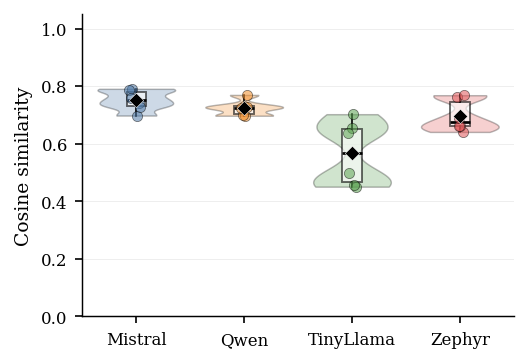

Saved: /content/results_slm_rag_eval/ieee_figures_article_color/fig01_violin_cosine_similarity.[pdf|svg|png]


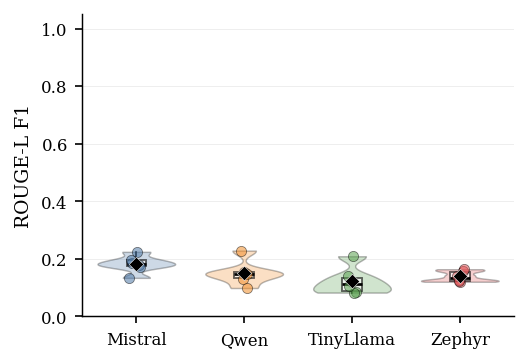

Saved: /content/results_slm_rag_eval/ieee_figures_article_color/fig02_violin_rougeL_f1.[pdf|svg|png]


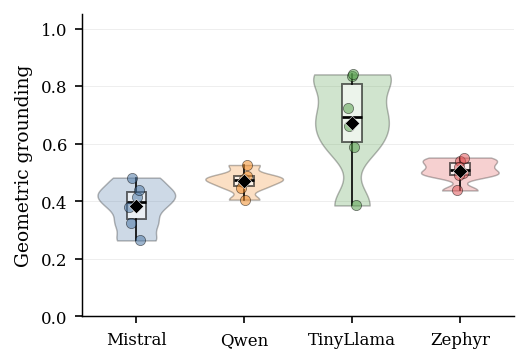

Saved: /content/results_slm_rag_eval/ieee_figures_article_color/fig03_violin_geometric_grounding.[pdf|svg|png]


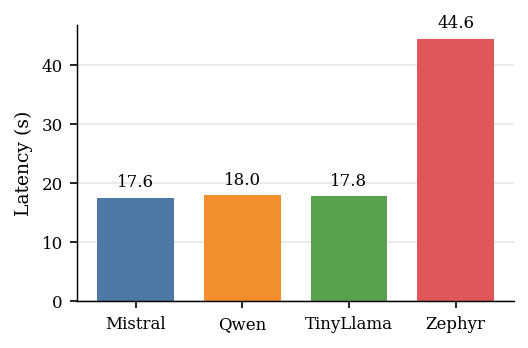

Saved: /content/results_slm_rag_eval/ieee_figures_article_color/fig04_bar_latency_seconds.[pdf|svg|png]


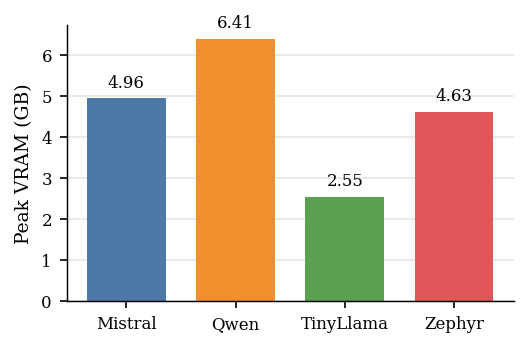

Saved: /content/results_slm_rag_eval/ieee_figures_article_color/fig05_bar_peak_vram_gb.[pdf|svg|png]


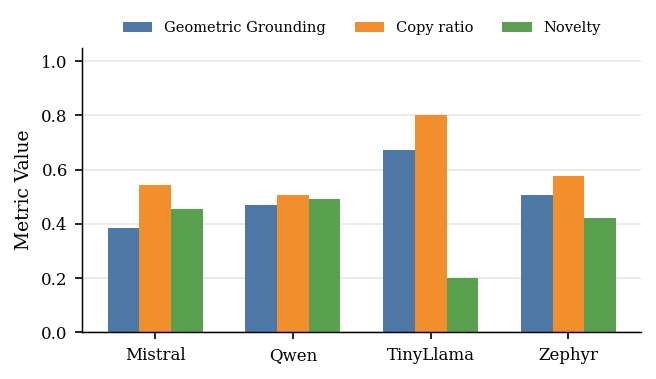

Saved: /content/results_slm_rag_eval/ieee_figures_article_color/fig06_grouped_grounding_copy_novelty.[pdf|svg|png]


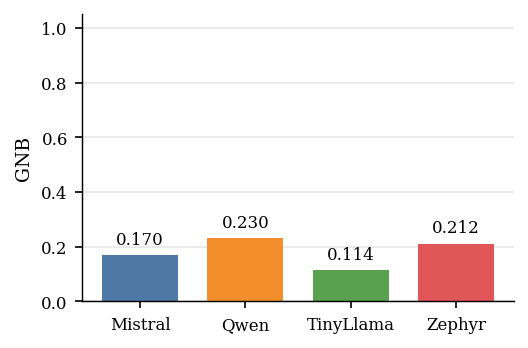

Saved: /content/results_slm_rag_eval/ieee_figures_article_color/fig_optional_bar_gnb.[pdf|svg|png]


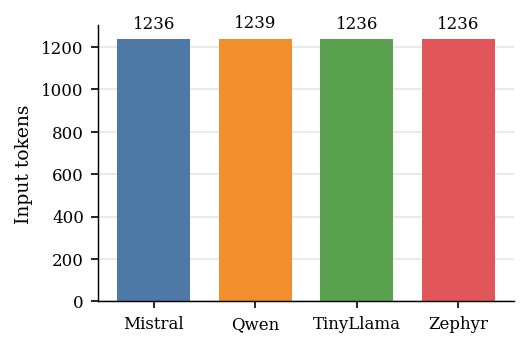

Saved: /content/results_slm_rag_eval/ieee_figures_article_color/fig_optional_bar_input_tokens.[pdf|svg|png]


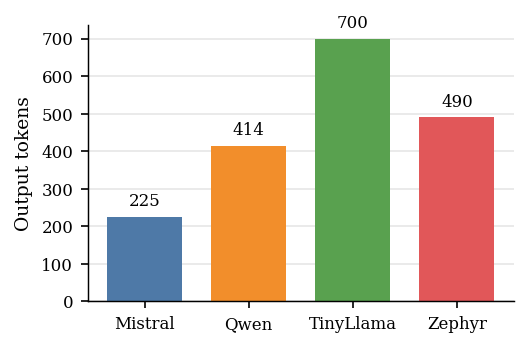

Saved: /content/results_slm_rag_eval/ieee_figures_article_color/fig_optional_bar_output_tokens.[pdf|svg|png]


,metric,model_short,mean,std,median,q1,q3,iqr,cv_percent,min,max,n
0,cosine_similarity,Mistral,0.751097,0.035153,0.751558,0.732807,0.778927,0.046120,4.680212,0.698008,0.790850,6.0
1,cosine_similarity,Qwen,0.724652,0.026471,0.724623,0.704859,0.731172,0.026313,3.652902,0.697423,0.769618,6.0
2,cosine_similarity,TinyLlama,0.566969,0.110735,0.568190,0.467583,0.650379,0.182796,19.531092,0.450882,0.702728,6.0
3,cosine_similarity,Zephyr,0.697574,0.055338,0.675874,0.660745,0.745148,0.084403,7.932982,0.641079,0.768675,6.0
4,rougeL_f1,Mistral,0.182200,0.029826,0.182598,0.174057,0.194439,0.020382,16.369789,0.134021,0.224390,6.0
5,rougeL_f1,Qwen,0.151483,0.043070,0.148462,0.133387,0.154363,0.020975,28.432245,0.098712,0.228571,6.0
6,rougeL_f1,TinyLlama,0.123412,0.047084,0.111833,0.089980,0.134695,0.044715,38.151666,0.082840,0.208955,6.0
7,rougeL_f1,Zephyr,0.138952,0.018575,0.133662,0.124470,0.153806,0.029336,13.367653,0.120527,0.163934,6.0
8,grounding_geometric_final,Mistral,0.383596,0.079285,0.396518,0.337949,0.431924,0.093975,20.668959,0.264105,0.482281,6.0
9,grounding_geometric_final,Qwen,0.469055,0.040636,0.473225,0.452075,0.486505,0.034430,8.663279,0.405758,0.526164,6.0


,model_short,grounding_geometric_final,copy_ratio,novelty
0,Mistral,0.383596,0.545094,0.454906
1,Qwen,0.469055,0.506846,0.493154
2,TinyLlama,0.672033,0.800354,0.199646
3,Zephyr,0.506369,0.578434,0.421566


,filename,metric,status
0,fig01_violin_cosine_similarity,Cosine similarity,main
1,fig02_violin_rougeL_f1,ROUGE-L F1,main
2,fig03_violin_geometric_grounding,Geometric grounding,main
3,fig04_bar_latency_seconds,Latency,main
4,fig05_bar_peak_vram_gb,Peak VRAM,main
5,fig06_grouped_grounding_copy_novelty,"Grounding, Copy Ratio and Novelty",main
6,fig_optional_bar_gnb,GNB,optional
7,fig_optional_bar_input_tokens,Input tokens,optional
8,fig_optional_bar_output_tokens,Output tokens,optional


Figures exported in: /content/results_slm_rag_eval/ieee_figures_article_color


In [24]:
# novo código para a geração dos gráficos

# ============================================================
# IEEE FIGURES - CLEAN ARTICLE VERSION
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path

PLOT_STYLE = "color"  # opções: "color" ou "ieee"

FIG_DIR = RESULTS_DIR / f"ieee_figures_article_{PLOT_STYLE}"
FIG_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "font.size": 9,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "axes.linewidth": 0.7,
    "grid.linewidth": 0.4,
    "savefig.dpi": 600,
    "figure.dpi": 150,
    "pdf.fonttype": 42,
    "ps.fonttype": 42
})

MODEL_ORDER = ["Mistral", "Qwen", "TinyLlama", "Zephyr"]

if PLOT_STYLE == "ieee":
    MODEL_COLORS = {
        "Mistral": "#4A4A4A",
        "Qwen": "#7A7A7A",
        "TinyLlama": "#B8B8B8",
        "Zephyr": "#D9D9D9"
    }
else:
    MODEL_COLORS = {
        "Mistral": "#4E79A7",
        "Qwen": "#F28E2B",
        "TinyLlama": "#59A14F",
        "Zephyr": "#E15759"
    }

def _save_figure(fig, filename):
    for ext in ["pdf", "svg", "png"]:
        fig.savefig(FIG_DIR / f"{filename}.{ext}", bbox_inches="tight", dpi=600)
    plt.show()
    plt.close(fig)
    print(f"Saved: {FIG_DIR / filename}.[pdf|svg|png]")

def _prepare_metric_values(df, metric):
    plot_df = df.copy()
    if "model_short" not in plot_df.columns:
        plot_df["model_short"] = plot_df["model_label"].apply(ieee_short_model_name)

    values = []
    summary_rows = []

    for model in MODEL_ORDER:
        vals = plot_df.loc[plot_df["model_short"] == model, metric].dropna().astype(float).values
        values.append(vals)

        if len(vals) > 0:
            mean = np.mean(vals)
            std = np.std(vals, ddof=1) if len(vals) > 1 else 0.0
            median = np.median(vals)
            q1 = np.percentile(vals, 25)
            q3 = np.percentile(vals, 75)
            iqr = q3 - q1
            cv = (std / mean) * 100 if mean != 0 else np.nan
            summary_rows.append({
                "model_short": model,
                "mean": mean,
                "std": std,
                "median": median,
                "q1": q1,
                "q3": q3,
                "iqr": iqr,
                "cv_percent": cv,
                "min": np.min(vals),
                "max": np.max(vals),
                "n": len(vals)
            })
        else:
            summary_rows.append({
                "model_short": model,
                "mean": np.nan,
                "std": np.nan,
                "median": np.nan,
                "q1": np.nan,
                "q3": np.nan,
                "iqr": np.nan,
                "cv_percent": np.nan,
                "min": np.nan,
                "max": np.nan,
                "n": 0
            })

    return values, pd.DataFrame(summary_rows)

def ieee_violin_box_plot(df, metric, ylabel, filename, ylim=None, show_mean=True):
    values, summary = _prepare_metric_values(df, metric)

    fig, ax = plt.subplots(figsize=(3.45, 2.35))
    positions = np.arange(1, len(MODEL_ORDER) + 1)

    violins = ax.violinplot(
        values,
        positions=positions,
        widths=0.72,
        showmeans=False,
        showmedians=False,
        showextrema=False,
        bw_method=0.35
    )

    for body, model in zip(violins["bodies"], MODEL_ORDER):
        body.set_facecolor(MODEL_COLORS[model])
        body.set_edgecolor("black")
        body.set_alpha(0.28)
        body.set_linewidth(0.7)

    ax.boxplot(
        values,
        positions=positions,
        widths=0.18,
        patch_artist=True,
        showfliers=False,
        showcaps=False,
        medianprops={"color": "black", "linewidth": 1.3},
        boxprops={"facecolor": "white", "edgecolor": "black", "linewidth": 0.9, "alpha": 0.60},
        whiskerprops={"color": "black", "linewidth": 0.8}
    )

    rng = np.random.default_rng(42)

    for i, (model, vals) in enumerate(zip(MODEL_ORDER, values), start=1):
        if len(vals) == 0:
            continue

        jitter = rng.normal(0, 0.035, size=len(vals))
        ax.scatter(
            np.full(len(vals), i) + jitter,
            vals,
            s=24,
            color=MODEL_COLORS[model],
            edgecolor="black",
            linewidth=0.35,
            alpha=0.55,
            zorder=4
        )

        if show_mean:
            ax.scatter(
                i,
                np.mean(vals),
                s=24,
                marker="D",
                color="black",
                edgecolor="white",
                linewidth=0.25,
                zorder=5
            )

    ax.set_ylabel(ylabel)
    ax.set_xticks(positions)
    ax.set_xticklabels(MODEL_ORDER, rotation=0)
    ax.grid(axis="y", linestyle="-", alpha=0.25)
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    if ylim is not None:
        ax.set_ylim(*ylim)
    elif metric in ["cosine_similarity", "rougeL_f1", "grounding_geometric_final"]:
        ax.set_ylim(0, 1.05)

    fig.tight_layout(pad=0.5)
    _save_figure(fig, filename)
    return summary

def _prepare_metric_summary(df, metric):
    plot_df = df.copy()
    if "model_short" not in plot_df.columns:
        plot_df["model_short"] = plot_df["model_label"].apply(ieee_short_model_name)

    summary = (
        plot_df.groupby("model_short", observed=False)[metric]
        .agg(["mean", "std"])
        .reset_index()
    )
    summary["model_short"] = pd.Categorical(summary["model_short"], categories=MODEL_ORDER, ordered=True)
    summary = summary.sort_values("model_short").reset_index(drop=True)
    summary["std"] = summary["std"].fillna(0.0)
    return summary

def clean_metric_barplot(df, metric, ylabel, filename, ylim=None, value_format="auto"):
    summary = _prepare_metric_summary(df, metric)

    fig, ax = plt.subplots(figsize=(3.45, 2.25))
    x = np.arange(len(summary))
    colors = [MODEL_COLORS[str(m)] for m in summary["model_short"]]

    bars = ax.bar(
          x,
          summary["mean"],
          color=colors,
          edgecolor="none" if PLOT_STYLE == "color" else "black",
          linewidth=0.5 if PLOT_STYLE == "ieee" else 0,
          width=0.72
      )

    # ax.bar(
    #     x,
    #     summary["mean"],
    #     color=colors,
    #     edgecolor="none" if PLOT_STYLE == "color" else "black",
    #     linewidth=0.5 if PLOT_STYLE == "ieee" else 0,
    #     width=0.72
    # )

    ax.set_ylabel(ylabel)
    ax.set_xticks(x)
    ax.set_xticklabels(summary["model_short"], rotation=0)
    ax.grid(axis="y", color="#E6E6E6", linewidth=0.8)
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    if ylim is not None:
        ax.set_ylim(*ylim)
    elif metric in ["copy_ratio", "novelty", "grounding_novelty_balance"]:
        ax.set_ylim(0, 1.05)

    y_min, y_max = ax.get_ylim()
    offset = (y_max - y_min) * 0.025

    for i, value in enumerate(summary["mean"]):
        if value_format == "3f":
            label = f"{value:.3f}"
        elif value_format == "2f":
            label = f"{value:.2f}"
        elif value_format == "1f":
            label = f"{value:.1f}"
        elif value_format == "0f":
            label = f"{value:.0f}"
        else:
            label = f"{value:.3f}" if abs(value) < 10 else f"{value:.1f}"

        ax.text(i, value + offset, label, ha="center", va="bottom", fontsize=8, fontweight="medium")

    fig.tight_layout(pad=0.5)
    _save_figure(fig, filename)
    return summary

def grouped_grounding_behavior_barplot(df, filename="fig06_grouped_grounding_copy_novelty"):
    plot_df = df.copy()
    if "model_short" not in plot_df.columns:
        plot_df["model_short"] = plot_df["model_label"].apply(ieee_short_model_name)

    metrics = [
        ("grounding_geometric_final", "Geometric Grounding"),
        ("copy_ratio", "Copy ratio"),
        ("novelty", "Novelty")
    ]

    summary = (
        plot_df.groupby("model_short", observed=False)[[m[0] for m in metrics]]
        .mean()
        .reindex(MODEL_ORDER)
        .reset_index()
    )

    fig, ax = plt.subplots(figsize=(4.3, 2.45))

    x = np.arange(len(MODEL_ORDER))
    width = 0.23

    if PLOT_STYLE == "ieee":
        metric_colors = ["#4A4A4A", "#8A8A8A", "#CFCFCF"]
    else:
        metric_colors = ["#4E79A7", "#F28E2B", "#59A14F"]

    for idx, (metric, label) in enumerate(metrics):
        offset = (idx - 1) * width
        bars = ax.bar(
            x + offset,
            summary[metric],
            width=width,
            label=label,
            color=metric_colors[idx],
            edgecolor="black" if PLOT_STYLE == "ieee" else "none",
            linewidth=0.25 if PLOT_STYLE == "ieee" else 0
        )

        # offsets = [0.02, 0.05, 0.08]

        # for bar in bars:
        #   value = bar.get_height()
        #   ax.text(
        #   bar.get_x() + bar.get_width() / 2,
        #   value + offsets[idx],   # usa um deslocamento diferente para cada métrica
        #   f"{value:.3f}",
        #   ha="center",
        #   va="bottom",
        #   fontsize=7

        #   )

        # for bar in bars:
        #     value = bar.get_height()
        #     ax.text(
        #         bar.get_x() + bar.get_width() / 2,
        #         value + 0.025,
        #         f"{value:.3f}",
        #         ha="center",
        #         va="bottom",
        #         fontsize=7
        #     )

    ax.set_ylabel("Metric Value")
    ax.set_xticks(x)
    ax.set_xticklabels(MODEL_ORDER, rotation=0)
    ax.set_ylim(0, 1.05)
    ax.grid(axis="y", color="#E6E6E6", linewidth=0.8)
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.legend(frameon=False, fontsize=7, loc="upper center", ncol=3, bbox_to_anchor=(0.5, 1.14))

    fig.tight_layout(pad=0.5)
    _save_figure(fig, filename)

    return summary

if not results_eval.empty:
    figure_manifest = []
    summaries = {}

    summaries["cosine_similarity"] = ieee_violin_box_plot(
        results_eval,
        "cosine_similarity",
        "Cosine similarity",
        "fig01_violin_cosine_similarity",
        ylim=(0, 1.05)
    )
    figure_manifest.append({"filename": "fig01_violin_cosine_similarity", "metric": "Cosine similarity", "status": "main"})

    summaries["rougeL_f1"] = ieee_violin_box_plot(
        results_eval,
        "rougeL_f1",
        "ROUGE-L F1",
        "fig02_violin_rougeL_f1",
        ylim=(0, 1.05)
    )
    figure_manifest.append({"filename": "fig02_violin_rougeL_f1", "metric": "ROUGE-L F1", "status": "main"})

    summaries["grounding_geometric_final"] = ieee_violin_box_plot(
        results_eval,
        "grounding_geometric_final",
        "Geometric grounding",
        "fig03_violin_geometric_grounding",
        ylim=(0, 1.05)
    )
    figure_manifest.append({"filename": "fig03_violin_geometric_grounding", "metric": "Geometric grounding", "status": "main"})

    summaries["latency_seconds"] = clean_metric_barplot(
        results_eval,
        "latency_seconds",
        "Latency (s)",
        "fig04_bar_latency_seconds",
        value_format="1f"
    )
    figure_manifest.append({"filename": "fig04_bar_latency_seconds", "metric": "Latency", "status": "main"})

    summaries["peak_vram_gb"] = clean_metric_barplot(
        results_eval,
        "peak_vram_gb",
        "Peak VRAM (GB)",
        "fig05_bar_peak_vram_gb",
        value_format="2f"
    )
    figure_manifest.append({"filename": "fig05_bar_peak_vram_gb", "metric": "Peak VRAM", "status": "main"})

    grounding_behavior_summary = grouped_grounding_behavior_barplot(
        results_eval,
        "fig06_grouped_grounding_copy_novelty"
    )
    figure_manifest.append({"filename": "fig06_grouped_grounding_copy_novelty", "metric": "Grounding, Copy Ratio and Novelty", "status": "main"})

    optional_specs = [
        ("grounding_novelty_balance", "GNB", "fig_optional_bar_gnb", "3f", (0, 1.05)),
        ("input_tokens", "Input tokens", "fig_optional_bar_input_tokens", "0f", None),
        ("output_tokens", "Output tokens", "fig_optional_bar_output_tokens", "0f", None),
    ]

    for metric, ylabel, filename, fmt, ylim in optional_specs:
        if metric in results_eval.columns:
            summaries[metric] = clean_metric_barplot(
                results_eval,
                metric,
                ylabel,
                filename,
                ylim=ylim,
                value_format=fmt
            )
            figure_manifest.append({"filename": filename, "metric": ylabel, "status": "optional"})

    rows = []
    for metric_name, metric_df in summaries.items():
        tmp = metric_df.copy()
        tmp.insert(0, "metric", metric_name)
        rows.append(tmp)

    if rows:
        figure_numeric_summary = pd.concat(rows, ignore_index=True)
        figure_numeric_summary.to_csv(FIG_DIR / "figure_numeric_summary.csv", index=False)
        display(figure_numeric_summary)

    grounding_behavior_summary.to_csv(FIG_DIR / "grounding_behavior_summary.csv", index=False)
    display(grounding_behavior_summary)

    figure_manifest = pd.DataFrame(figure_manifest)
    figure_manifest.to_csv(FIG_DIR / "figure_manifest.csv", index=False)
    display(figure_manifest)

    print("Figures exported in:", FIG_DIR)

else:
    print("results_eval is empty. Figures were not generated.")

NOVAS MÉTRICAS TEXTUAIS
Somente relatórios válidos: False
Linhas utilizadas: 24

Amostras por modelo:


,model_short,n
0,Mistral,6
1,Qwen,6
2,TinyLlama,6
3,Zephyr,6


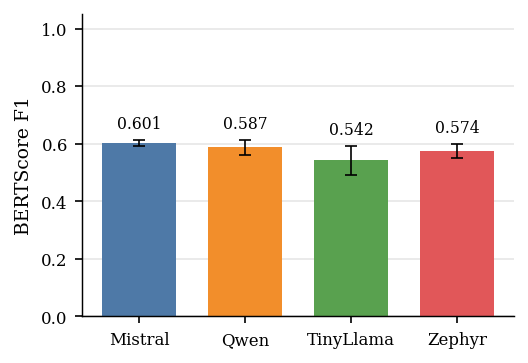

Saved: /content/results_slm_rag_eval/ieee_figures_article_color/fig07_bar_bertscore_f1.[pdf|svg|png]


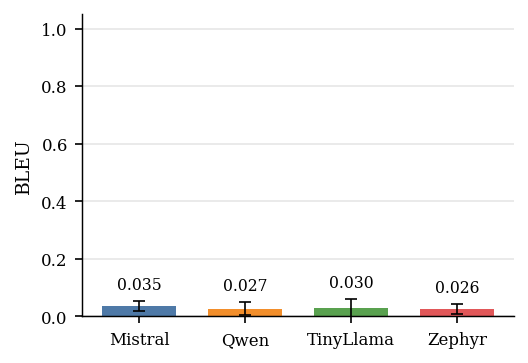

Saved: /content/results_slm_rag_eval/ieee_figures_article_color/fig08_bar_bleu.[pdf|svg|png]


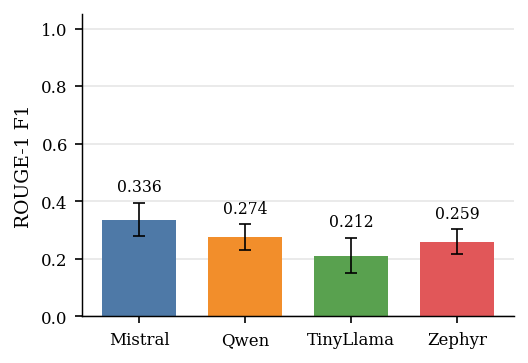

Saved: /content/results_slm_rag_eval/ieee_figures_article_color/fig09_bar_rouge1_f1.[pdf|svg|png]


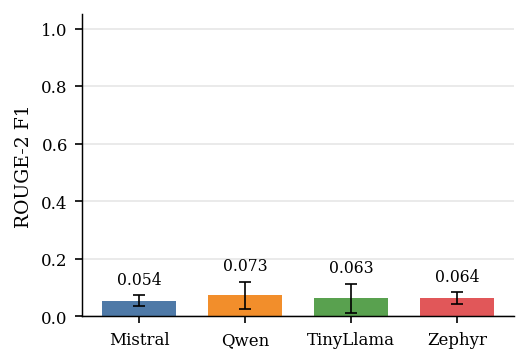

Saved: /content/results_slm_rag_eval/ieee_figures_article_color/fig10_bar_rouge2_f1.[pdf|svg|png]

RESUMO DAS NOVAS MÉTRICAS


bertscore_f1            bleu         rouge1_f1         rouge2_f1  \
                    mean     std    mean     std      mean     std      mean   
model_short                                                                    
Mistral           0.6014  0.0106  0.0355  0.0175    0.3359  0.0578    0.0545   
Qwen              0.5874  0.0272  0.0269  0.0229    0.2743  0.0452    0.0733   
TinyLlama         0.5418  0.0509  0.0296  0.0314    0.2116  0.0602    0.0633   
Zephyr            0.5743  0.0249  0.0263  0.0165    0.2590  0.0437    0.0636   

                     
                std  
model_short          
Mistral      0.0183  
Qwen         0.0468  
TinyLlama    0.0510  
Zephyr       0.0195


Gráficos e tabelas das novas métricas salvos em: /content/results_slm_rag_eval/ieee_figures_article_color


In [27]:
# ============================================================
# FIGURAS IEEE — NOVAS MÉTRICAS TEXTUAIS
#
# BERTScore F1
# BLEU
# ROUGE-1 F1
# ROUGE-2 F1
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# CONTROLE DO TINYLLAMA
# ------------------------------------------------------------
# False:
#   inclui todas as saídas, inclusive relatórios truncados.
#
# True:
#   utiliza somente relatórios válidos e não truncados.
#
# Para a análise principal inicial, recomendo manter False
# e apresentar a validade/truncamento separadamente.
FILTER_VALID_ONLY = False


def prepare_text_metric_dataframe(
    df: pd.DataFrame,
    valid_only: bool = False
) -> pd.DataFrame:
    """
    Prepara o DataFrame para os gráficos das métricas textuais.
    """

    plot_df = df.copy()

    if "model_short" not in plot_df.columns:
        plot_df["model_short"] = (
            plot_df["model_label"]
            .apply(ieee_short_model_name)
        )

    if valid_only:

        valid_mask = pd.Series(
            True,
            index=plot_df.index
        )

        if "valid_report" in plot_df.columns:
            valid_mask &= (
                plot_df["valid_report"]
                .fillna(False)
                .astype(bool)
            )

        if "was_truncated" in plot_df.columns:
            valid_mask &= ~(
                plot_df["was_truncated"]
                .fillna(False)
                .astype(bool)
            )

        plot_df = plot_df.loc[
            valid_mask
        ].copy()

    return plot_df


def text_metric_barplot_with_error(
    df: pd.DataFrame,
    metric: str,
    ylabel: str,
    filename: str,
    ylim=(0, 1.05),
    decimals: int = 3
) -> pd.DataFrame:
    """
    Gráfico IEEE de média ± desvio-padrão por modelo.
    """

    if metric not in df.columns:
        raise KeyError(
            f"A coluna '{metric}' não existe em results_eval. "
            "Execute primeiro a célula das métricas adicionais."
        )

    summary = (
        df
        .groupby(
            "model_short",
            observed=False
        )[metric]
        .agg(
            mean="mean",
            std="std",
            median="median",
            minimum="min",
            maximum="max",
            n="count",
        )
        .reindex(MODEL_ORDER)
        .reset_index()
    )

    summary["std"] = (
        summary["std"]
        .fillna(0.0)
    )

    fig, ax = plt.subplots(
        figsize=(3.45, 2.35)
    )

    x = np.arange(
        len(summary)
    )

    colors = [
        MODEL_COLORS[model]
        for model in summary["model_short"]
    ]

    bars = ax.bar(
        x,
        summary["mean"],
        yerr=summary["std"],
        capsize=3,
        width=0.70,
        color=colors,
        edgecolor=(
            "black"
            if PLOT_STYLE == "ieee"
            else "none"
        ),
        linewidth=(
            0.5
            if PLOT_STYLE == "ieee"
            else 0
        ),
        error_kw={
            "elinewidth": 0.8,
            "capthick": 0.8,
        },
    )

    ax.set_ylabel(ylabel)

    ax.set_xticks(x)

    ax.set_xticklabels(
        summary["model_short"],
        rotation=0
    )

    ax.grid(
        axis="y",
        color="#E6E6E6",
        linewidth=0.8
    )

    ax.set_axisbelow(True)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    if ylim is not None:
        ax.set_ylim(*ylim)

    y_min, y_max = ax.get_ylim()

    label_offset = (
        y_max - y_min
    ) * 0.025

    for bar, value, std in zip(
        bars,
        summary["mean"],
        summary["std"],
    ):
        if pd.isna(value):
            continue

        label_y = (
            value
            + std
            + label_offset
        )

        ax.text(
            bar.get_x()
            + bar.get_width() / 2,
            label_y,
            f"{value:.{decimals}f}",
            ha="center",
            va="bottom",
            fontsize=7.5,
            fontweight="medium",
        )

    fig.tight_layout(
        pad=0.5
    )

    _save_figure(
        fig,
        filename
    )

    return summary


# ============================================================
# DATAFRAME USADO NOS GRÁFICOS
# ============================================================

text_metrics_plot_df = (
    prepare_text_metric_dataframe(
        results_eval,
        valid_only=FILTER_VALID_ONLY
    )
)

print("=" * 75)
print("NOVAS MÉTRICAS TEXTUAIS")
print("=" * 75)
print(
    "Somente relatórios válidos:",
    FILTER_VALID_ONLY
)
print(
    "Linhas utilizadas:",
    len(text_metrics_plot_df)
)

print("\nAmostras por modelo:")

display(
    text_metrics_plot_df
    .groupby("model_short")
    .size()
    .rename("n")
    .reindex(MODEL_ORDER)
    .reset_index()
)


# ============================================================
# GERAÇÃO DOS QUATRO GRÁFICOS
# ============================================================

new_metric_summaries = {}


new_metric_summaries[
    "bertscore_f1"
] = text_metric_barplot_with_error(
    text_metrics_plot_df,
    metric="bertscore_f1",
    ylabel="BERTScore F1",
    filename="fig07_bar_bertscore_f1",
    ylim=(0, 1.05),
    decimals=3,
)


new_metric_summaries[
    "bleu"
] = text_metric_barplot_with_error(
    text_metrics_plot_df,
    metric="bleu",
    ylabel="BLEU",
    filename="fig08_bar_bleu",
    ylim=(0, 1.05),
    decimals=3,
)


new_metric_summaries[
    "rouge1_f1"
] = text_metric_barplot_with_error(
    text_metrics_plot_df,
    metric="rouge1_f1",
    ylabel="ROUGE-1 F1",
    filename="fig09_bar_rouge1_f1",
    ylim=(0, 1.05),
    decimals=3,
)


new_metric_summaries[
    "rouge2_f1"
] = text_metric_barplot_with_error(
    text_metrics_plot_df,
    metric="rouge2_f1",
    ylabel="ROUGE-2 F1",
    filename="fig10_bar_rouge2_f1",
    ylim=(0, 1.05),
    decimals=3,
)


# ============================================================
# TABELA CONSOLIDADA DAS NOVAS MÉTRICAS
# ============================================================

new_metrics_summary_table = (
    text_metrics_plot_df
    .groupby(
        "model_short",
        observed=False
    )[
        [
            "bertscore_f1",
            "bleu",
            "rouge1_f1",
            "rouge2_f1",
        ]
    ]
    .agg(
        [
            "mean",
            "std",
        ]
    )
    .reindex(MODEL_ORDER)
    .round(4)
)

print(
    "\nRESUMO DAS NOVAS MÉTRICAS"
)

display(
    new_metrics_summary_table
)


# ============================================================
# EXPORTAÇÃO DOS RESUMOS
# ============================================================

for metric_name, summary_df in (
    new_metric_summaries.items()
):
    summary_df.to_csv(
        FIG_DIR
        / f"summary_{metric_name}.csv",
        index=False,
    )

new_metrics_summary_table.to_csv(
    FIG_DIR
    / "summary_new_text_metrics.csv"
)

print(
    "\nGráficos e tabelas das novas métricas "
    f"salvos em: {FIG_DIR}"
)

## 15. Exportação de tabelas em LaTeX no padrão do artigo

As tabelas abaixo são separadas por função metodológica:

- métricas tradicionais;
- métricas propostas/interpretativas;
- eficiência computacional.

Não são exportadas tabelas com scores compostos ponderados.


In [25]:

# ============================================================
# IEEE-STYLE LATEX TABLES - CLEAN ARTICLE VERSION
# ============================================================

TABLE_DIR = RESULTS_DIR / "ieee_tables_clean_article"
TABLE_DIR.mkdir(parents=True, exist_ok=True)


def _mean_std_table(df, metrics, model_col="model_short"):
    tmp = df.copy()
    if model_col not in tmp.columns:
        tmp[model_col] = tmp["model_label"].apply(ieee_short_model_name)

    rows = []
    for model in MODEL_ORDER:
        sub = tmp[tmp[model_col] == model]
        if sub.empty:
            continue
        row = {"Model": model}
        for metric, label, decimals in metrics:
            if metric in sub.columns:
                mean = sub[metric].mean()
                std = sub[metric].std()
                if pd.isna(std):
                    std = 0.0
                row[label] = f"{mean:.{decimals}f} $\\pm$ {std:.{decimals}f}"
        rows.append(row)
    return pd.DataFrame(rows)


def _write_table_tex(df, filename, caption, label):
    tex = df.to_latex(index=False, escape=False)
    tex = tex.replace("\\begin{tabular}", "\\caption{" + caption + "}\n\\label{" + label + "}\n\\begin{tabular}")
    tex = tex.replace("\\toprule", "\\hline")
    tex = tex.replace("\\midrule", "\\hline")
    tex = tex.replace("\\bottomrule", "\\hline")
    out = TABLE_DIR / filename
    with open(out, "w", encoding="utf-8") as f:
        f.write(tex)
    print("Saved:", out)
    return tex


if not results_eval.empty:
    traditional_metrics = [
        ("cosine_similarity", "Cosine", 3),
        ("rougeL_f1", "ROUGE-L", 3),
        ("grounding_geometric_final", "Geometric grounding", 3),
    ]

    grounding_behavior_metrics = [
        ("grounding_geometric_final", "G", 3),
        ("copy_ratio", "CR", 3),
        ("novelty", "N", 3),
        ("grounding_novelty_balance", "GNB", 3),
    ]

    efficiency_metrics = [
        ("latency_seconds", "Latency (s)", 2),
        ("peak_vram_gb", "VRAM (GB)", 2),
        ("input_tokens", "Input tokens", 1),
        ("output_tokens", "Output tokens", 1),
    ]

    table_traditional_ieee = _mean_std_table(results_eval, traditional_metrics)
    table_grounding_behavior_ieee = _mean_std_table(results_eval, grounding_behavior_metrics)
    table_efficiency_ieee = _mean_std_table(results_eval, efficiency_metrics)

    display(table_traditional_ieee)
    display(table_grounding_behavior_ieee)
    display(table_efficiency_ieee)

    table_traditional_ieee.to_csv(TABLE_DIR / "table_traditional_metrics.csv", index=False)
    table_grounding_behavior_ieee.to_csv(TABLE_DIR / "table_grounding_behavior_metrics.csv", index=False)
    table_efficiency_ieee.to_csv(TABLE_DIR / "table_efficiency_metrics.csv", index=False)

    _write_table_tex(
        table_traditional_ieee,
        "table_traditional_metrics.tex",
        "Traditional quality metrics obtained for each evaluated SLM.",
        "tab:traditional_metrics"
    )

    _write_table_tex(
        table_grounding_behavior_ieee,
        "table_grounding_behavior_metrics.tex",
        "Grounding-oriented and generative-behavior metrics obtained for each evaluated SLM.",
        "tab:grounding_behavior_metrics"
    )

    _write_table_tex(
        table_efficiency_ieee,
        "table_efficiency_metrics.tex",
        "Computational efficiency metrics obtained for each evaluated SLM.",
        "tab:efficiency_metrics"
    )

    print("Clean IEEE tables exported in:", TABLE_DIR)
else:
    print("results_eval is empty. IEEE tables were not generated.")


,Model,Cosine,ROUGE-L,Geometric grounding
0,Mistral,0.751 $\pm$ 0.035,0.182 $\pm$ 0.030,0.384 $\pm$ 0.079
1,Qwen,0.725 $\pm$ 0.026,0.151 $\pm$ 0.043,0.469 $\pm$ 0.041
2,TinyLlama,0.567 $\pm$ 0.111,0.123 $\pm$ 0.047,0.672 $\pm$ 0.172
3,Zephyr,0.698 $\pm$ 0.055,0.139 $\pm$ 0.019,0.506 $\pm$ 0.041


,Model,G,CR,N,GNB
0,Mistral,0.384 $\pm$ 0.079,0.545 $\pm$ 0.088,0.455 $\pm$ 0.088,0.170 $\pm$ 0.021
1,Qwen,0.469 $\pm$ 0.041,0.507 $\pm$ 0.043,0.493 $\pm$ 0.043,0.230 $\pm$ 0.019
2,TinyLlama,0.672 $\pm$ 0.172,0.800 $\pm$ 0.159,0.200 $\pm$ 0.159,0.114 $\pm$ 0.064
3,Zephyr,0.506 $\pm$ 0.041,0.578 $\pm$ 0.075,0.422 $\pm$ 0.075,0.212 $\pm$ 0.025


,Model,Latency (s),VRAM (GB),Input tokens,Output tokens
0,Mistral,17.62 $\pm$ 3.53,4.96 $\pm$ 0.00,1235.7 $\pm$ 0.8,225.2 $\pm$ 47.7
1,Qwen,17.97 $\pm$ 3.57,6.41 $\pm$ 0.00,1239.0 $\pm$ 7.0,414.0 $\pm$ 79.9
2,TinyLlama,17.85 $\pm$ 1.61,2.55 $\pm$ 0.00,1236.2 $\pm$ 0.8,700.0 $\pm$ 0.0
3,Zephyr,44.57 $\pm$ 11.75,4.63 $\pm$ 0.00,1236.2 $\pm$ 1.0,490.3 $\pm$ 130.9


Saved: /content/results_slm_rag_eval/ieee_tables_clean_article/table_traditional_metrics.tex
Saved: /content/results_slm_rag_eval/ieee_tables_clean_article/table_grounding_behavior_metrics.tex
Saved: /content/results_slm_rag_eval/ieee_tables_clean_article/table_efficiency_metrics.tex
Clean IEEE tables exported in: /content/results_slm_rag_eval/ieee_tables_clean_article


## 16. Checklist final

Ao final, verificar se os seguintes arquivos foram gerados:

- `efficiency_summary_results.csv`
- `quality_summary_results.csv`
- `model_ranking_summary.csv`
- `results_with_quality_metrics.csv`
- `grid_with_quality_metrics.csv`
- `best_grid_configuration_by_model.csv`
- `ieee_figures_numeric_summary.csv`
- pasta `ieee_figures/` com figuras em `.pdf`, `.svg` e `.png`
- pasta `ieee_tables/` com tabelas `.tex`

Observação: os gráficos principais usam métricas diretas. Os scores compostos foram mantidos apenas nas tabelas de ranking.


In [26]:

print('Arquivos gerados:')
for p in sorted(RESULTS_DIR.rglob('*')):
    if p.is_file():
        print('-', p)

print('\nChecklist metodológico:')
print('✓ BLEU removido da análise principal')
print('✓ Grounding ponderado 70/30 removido das figuras e tabelas finais')
print('✓ Scores compostos ponderados removidos')
print('✓ Geometric Grounding usado como métrica principal de grounding')
print('✓ Copy Ratio, Novelty e GNB calculados como métricas interpretativas')
print('✓ Figuras principais e complementares exportadas em PDF, SVG e PNG')


Arquivos gerados:
- /content/results_slm_rag_eval/article_metrics_summary_grid.csv
- /content/results_slm_rag_eval/article_metrics_summary_results.csv
- /content/results_slm_rag_eval/efficiency_summary_grid.csv
- /content/results_slm_rag_eval/efficiency_summary_results.csv
- /content/results_slm_rag_eval/grid_descriptive_summary_no_composite_scores.csv
- /content/results_slm_rag_eval/grid_eval_article_metrics_clean.csv
- /content/results_slm_rag_eval/grid_with_all_metrics.csv
- /content/results_slm_rag_eval/grounding_novelty_balance_correlation.csv
- /content/results_slm_rag_eval/grounding_novelty_balance_summary.csv
- /content/results_slm_rag_eval/ieee_figures_article_color/fig01_violin_cosine_similarity.pdf
- /content/results_slm_rag_eval/ieee_figures_article_color/fig01_violin_cosine_similarity.png
- /content/results_slm_rag_eval/ieee_figures_article_color/fig01_violin_cosine_similarity.svg
- /content/results_slm_rag_eval/ieee_figures_article_color/fig02_violin_rougeL_f1.pdf
- /cont

In [28]:
from shutil import make_archive
from google.colab import files

zip_path = make_archive(
    "/content/results_slm_rag_eval",
    "zip",
    "/content/results_slm_rag_eval"
)

files.download(zip_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>